In [22]:
import matplotlib.pyplot as plt
import pandas

In [23]:
df:pandas.DataFrame = pandas.read_csv('datas.csv')

df["P_var_mc"] = df["|A∩B_mc|"]/df["|B_mc|"] # precision
df["R_var_mc"] = df["|A∩B_mc|"]/df["|A|"] # recall
df["P_var_pggb"] = df["|A∩B_pggb|"]/df["|B_pggb|"]
df["R_var_pggb"] = df["|A∩B_pggb|"]/df["|A|"]


df["Ed_mc"] = df["M_mc"]+df["S_mc"]
df["Ed_pggb"] = df["M_pggb"]+df["S_pggb"]
df["Rd_mc"] = (df["M_mc"]+df["S_mc"])/(df["M_mc"]+df["S_mc"]+df["E_mc"])
df["Rd_pggb"] = (df["M_pggb"]+df["S_pggb"])/(df["M_pggb"]+df["S_pggb"]+df["E_pggb"])
df["Rb_mc"] = (df["S_mc"])/(df["M_mc"]+df["S_mc"])
df["Rb_pggb"] = (df["S_pggb"])/(df["M_pggb"]+df["S_pggb"])
df["P_edit_mc"] = (df["E_mc"])/(df["M_mc"]+df["E_mc"])
df["P_edit_pggb"] = (df["E_pggb"])/(df["M_pggb"]+df["E_pggb"])
df["R_edit_mc"] = (df["E_mc"])/(df["S_mc"]+df["E_mc"])
df["R_edit_pggb"] = (df["E_pggb"])/(df["S_pggb"]+df["E_pggb"])

In [24]:
df


,Sp.,Cond.,µ,Rep.,|A|,|B_mc|,|B_pggb|,|A∩B_mc|,|A∩B_pggb|,|Ω|,...,Ed_mc,Ed_pggb,Rd_mc,Rd_pggb,Rb_mc,Rb_pggb,P_edit_mc,P_edit_pggb,R_edit_mc,R_edit_pggb
0,manul,C,10000000,rep2,3070235,3188561,3247230,2792850,2844768,421552966,...,202788,239863,0.038933,0.045770,0.436175,0.390223,0.977669,0.971583,0.982637,0.981627
1,yeast,C,10000000,rep10,20376,20575,20587,20048,20146,2220083,...,1229,1280,0.043337,0.045152,0.471115,0.500000,0.976602,0.976903,0.979104,0.976903
2,yeast,A,10000000,rep8,16957,16950,16950,16439,16439,2224240,...,120,120,0.001805,0.001805,0.916667,0.916667,0.999849,0.999849,0.998346,0.998346
3,aspergillus,A,10000000,rep3,98084,98097,98097,96466,96466,29649910,...,1220,200,0.003123,0.000513,0.163934,1.000000,0.997387,1.000000,0.999487,0.999487
4,aspergillus,C,10000000,rep5,240846,247477,241529,230727,232329,29666279,...,15031,14684,0.033338,0.032612,0.467767,0.496799,0.981976,0.983319,0.984124,0.983528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,synthetic,A,10000000,rep5,125988,126030,126030,122468,122468,30000000,...,160,100,0.000321,0.000200,0.625000,1.000000,0.999880,1.000000,0.999800,0.999800
203,synthetic,G,10000000,rep4,1112651,7694858,841547,652096,452453,30000000,...,301478,479327,0.962039,0.968936,0.034609,0.014527,0.039269,0.031507,0.532736,0.688177
204,synthetic,C,10000000,rep3,151982,157677,156157,133766,125384,30002618,...,11654,9912,0.041799,0.035812,0.406127,0.506659,0.974748,0.982006,0.982592,0.981529
205,synthetic,F,10000000,rep5,167670,139842,124108,66532,57522,30000000,...,85818,84250,0.971341,0.970577,0.010231,0.010160,0.028946,0.029716,0.742522,0.748974


In [25]:
df_indel = df[(df['Cond.'] == 'A') | (df['Cond.'] == 'B') |(df['Cond.'] == 'C') |(df['Cond.'] == 'H') |(df['Cond.'] == 'I')]
df_inv = df[(df['Cond.'] == 'A') | (df['Cond.'] == 'D') |(df['Cond.'] == 'E') |(df['Cond.'] == 'F') |(df['Cond.'] == 'G')]

Text(0.5, 0.98, 'Éditions entre graphe MSpangepop et PGGB')

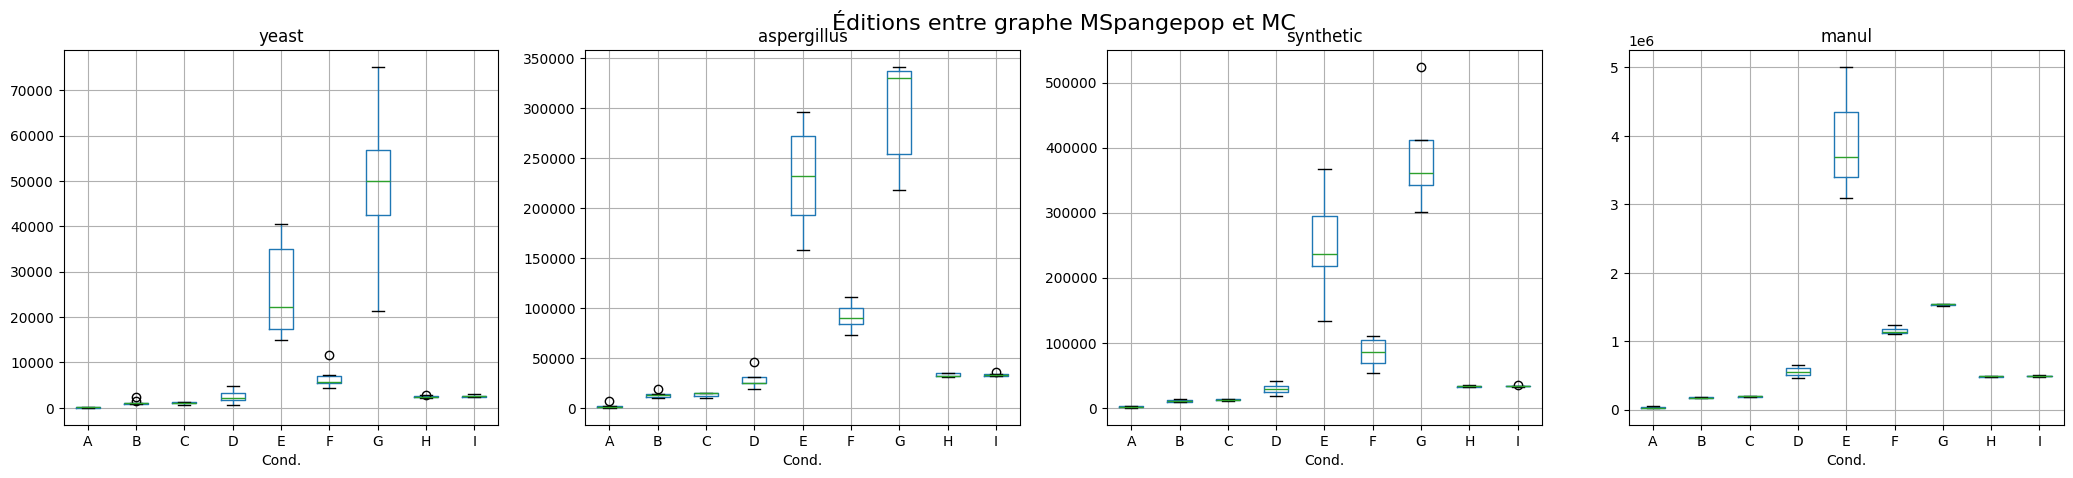

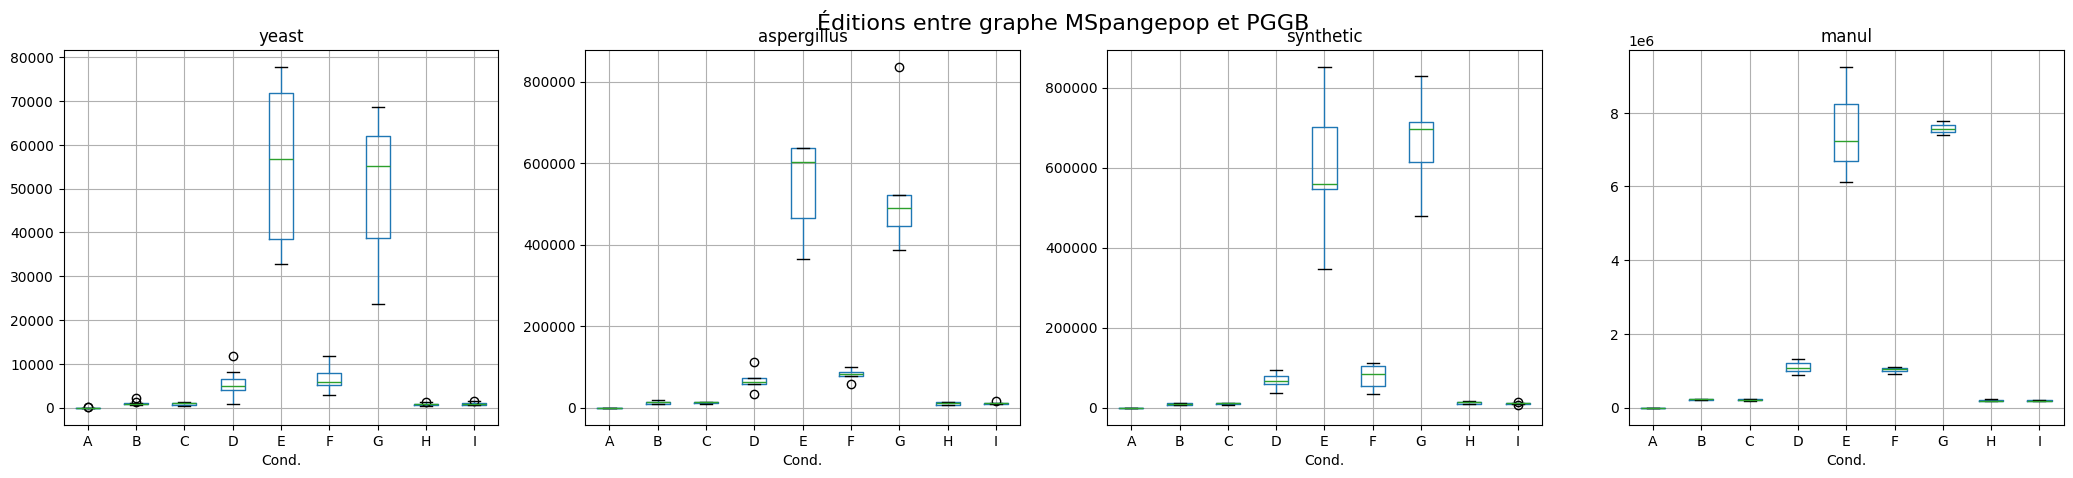

In [26]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Ed_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Éditions entre graphe MSpangepop et MC', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Ed_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Éditions entre graphe MSpangepop et PGGB', fontsize=16)

In [27]:
result = df.groupby(['Cond.'], as_index=False).agg(
                    {'Ed_mc':['sum']})
print(result)

result = df.groupby(['Cond.'], as_index=False).agg(
                    {'Ed_pggb':['sum']})
print(result)

  Cond.     Ed_mc
              sum
0     A    128370
1     B    667045
2     C    715731
3     D   1986778
4     E  14461154
5     F   4413231
6     G   8523309
7     H   1817968
8     I   1833614
  Cond.   Ed_pggb
              sum
0     A      6599
1     B    798140
2     C    768447
3     D   4040805
4     E  28877990
5     F   3933837
6     G  29251615
7     H    713962
8     I    694261


manul
  Cond.  P_var_mc          
             mean       std
0     A  0.973318  0.004813
1     B  0.905119  0.006075
2     C  0.852661  0.028316
3     D  0.785857  0.023893
4     E  0.665027  0.049507
5     F  0.012994  0.001272
6     G  0.055043  0.003630
7     H  0.463820  0.027424
8     I  0.086776  0.002105
manul
  Cond.  R_var_mc          
             mean       std
0     A  0.973517  0.004866
1     B  0.905232  0.005988
2     C  0.903140  0.012216
3     D  0.665630  0.022630
4     E  0.648905  0.020996
5     F  0.535050  0.018422
6     G  0.919563  0.032657
7     H  0.463735  0.026999
8     I  0.622542  0.023507


Text(0.5, 0.98, 'Variant recall for MC')

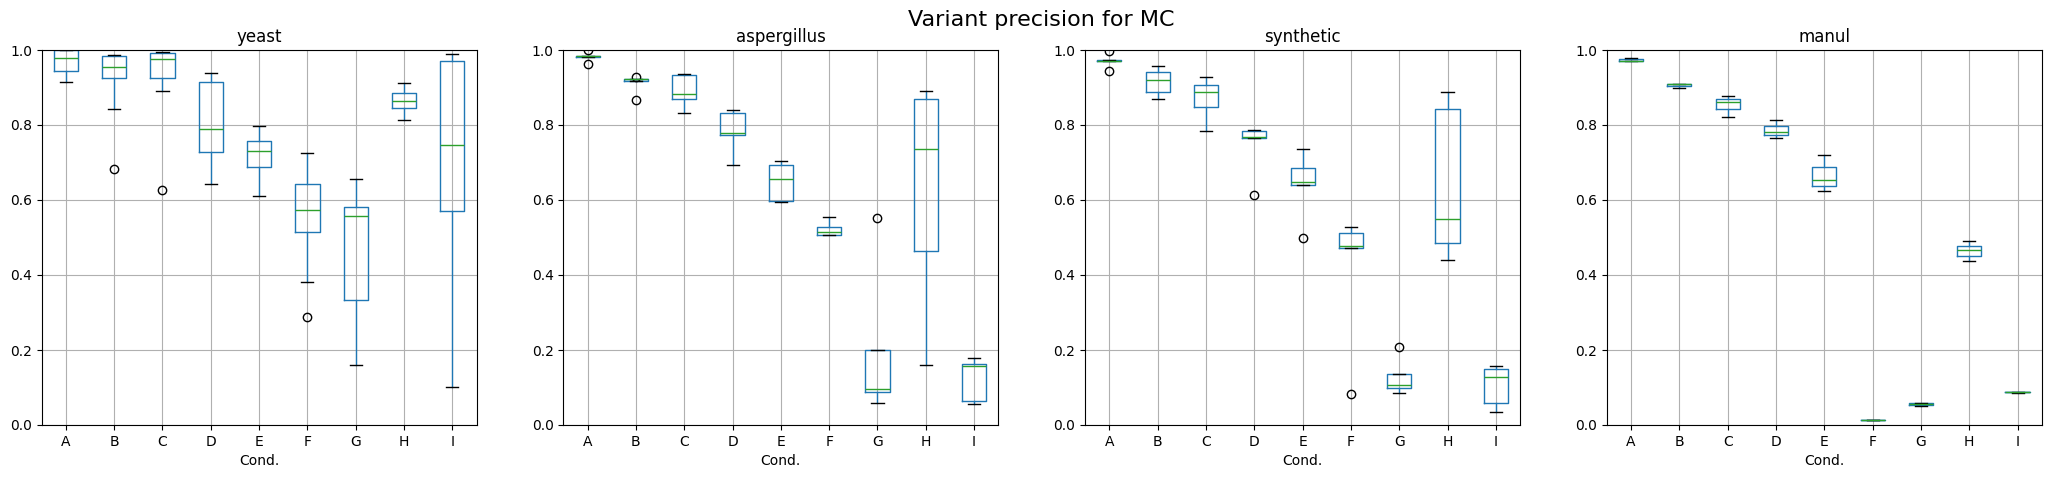

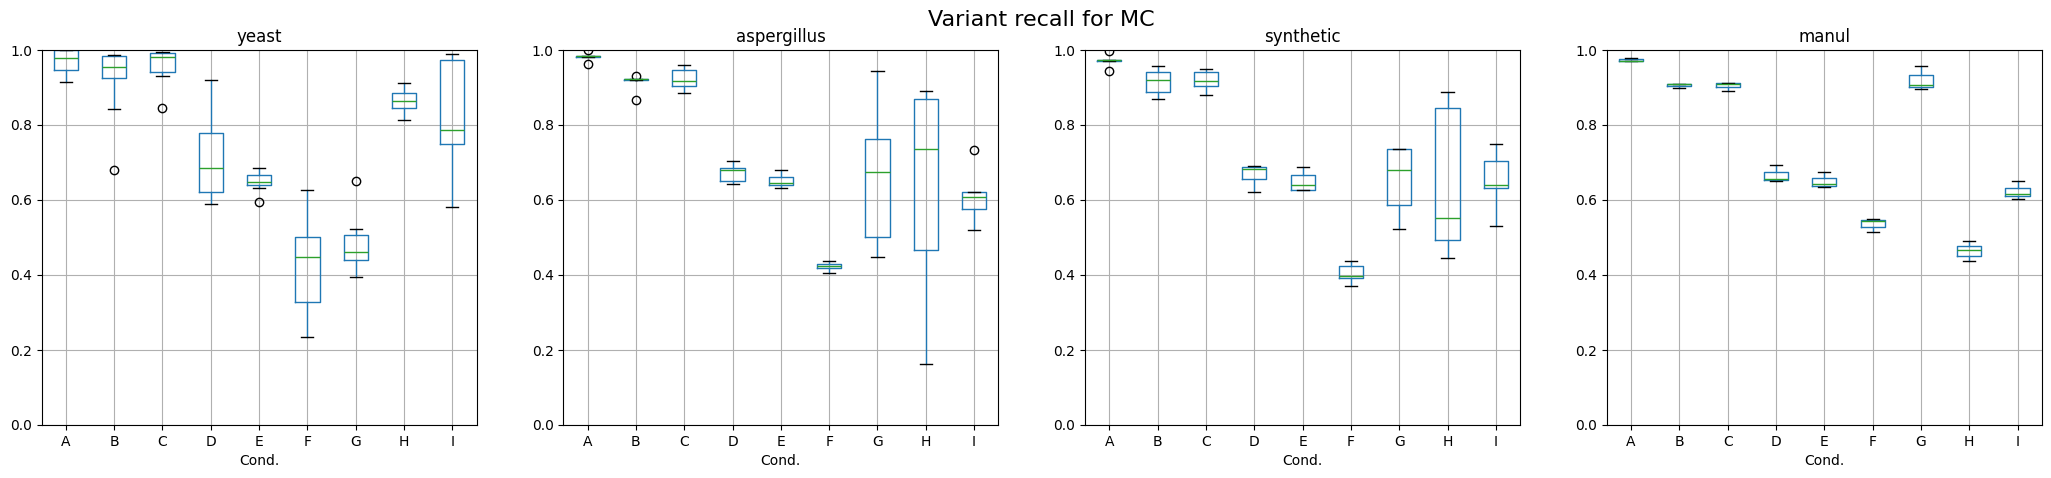

In [28]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="P_var_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
    if label_cond == 'manul':
        print(label_cond)
        result = cl.groupby(['Cond.'], as_index=False).agg(
                            {'P_var_mc':['mean','std']})
        print(result)
fig.suptitle('Variant precision for MC', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="R_var_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)

    if label_cond == 'manul':
        print(label_cond)
        result = cl.groupby(['Cond.'], as_index=False).agg(
                            {'R_var_mc':['mean','std']})
        print(result)
fig.suptitle('Variant recall for MC', fontsize=16)

manul
  Cond. P_var_pggb          
              mean       std
0     A   0.973371  0.005100
1     B   0.794802  0.009299
2     C   0.882329  0.016435
3     D   0.774972  0.007823
4     E   0.727259  0.017729
5     F   0.509130  0.015362
6     G   0.550341  0.004467
7     H   0.428138  0.072657
8     I   0.754965  0.078330
manul
  Cond. R_var_pggb          
              mean       std
0     A   0.973622  0.004980
1     B   0.901858  0.004514
2     C   0.931134  0.011727
3     D   0.591100  0.001945
4     E   0.570376  0.029068
5     F   0.387639  0.007185
6     G   0.456709  0.001667
7     H   0.528829  0.020669
8     I   0.801918  0.051035


Text(0.5, 0.98, 'Variant recall for PGGB')

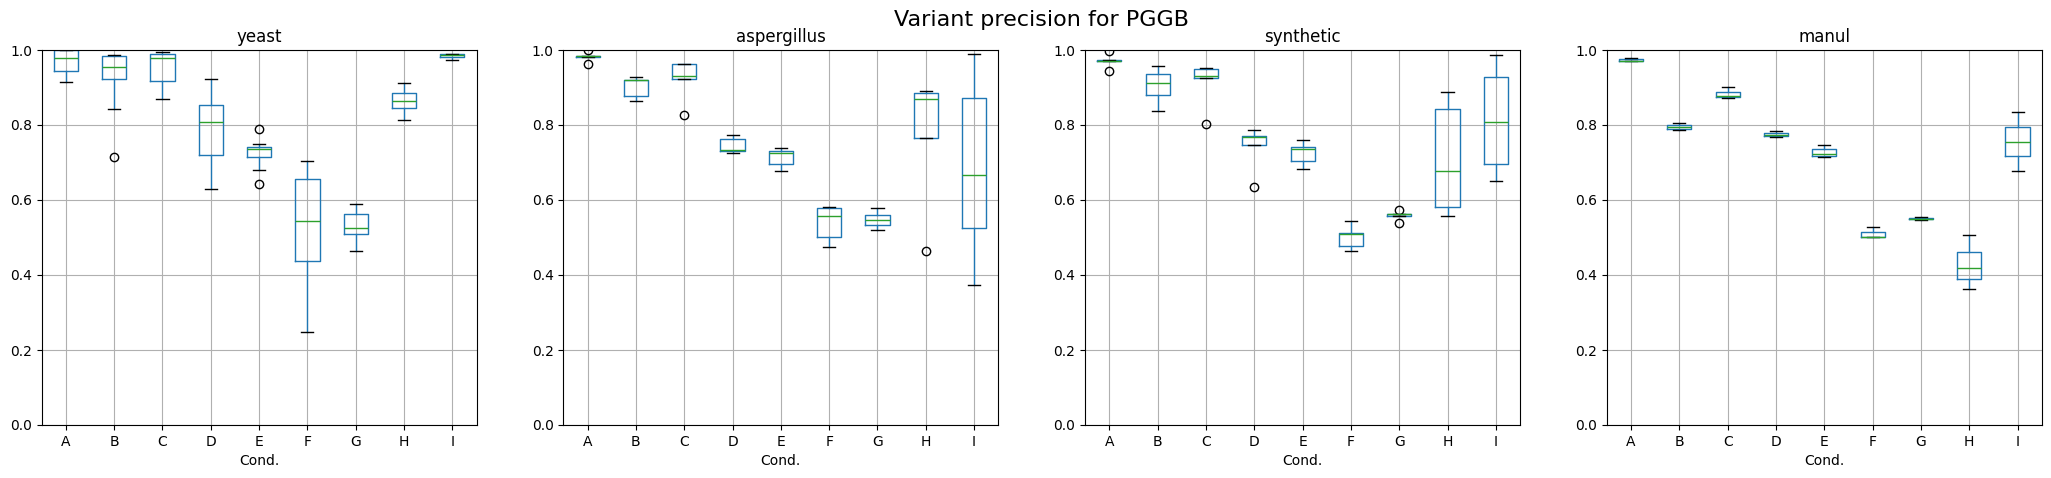

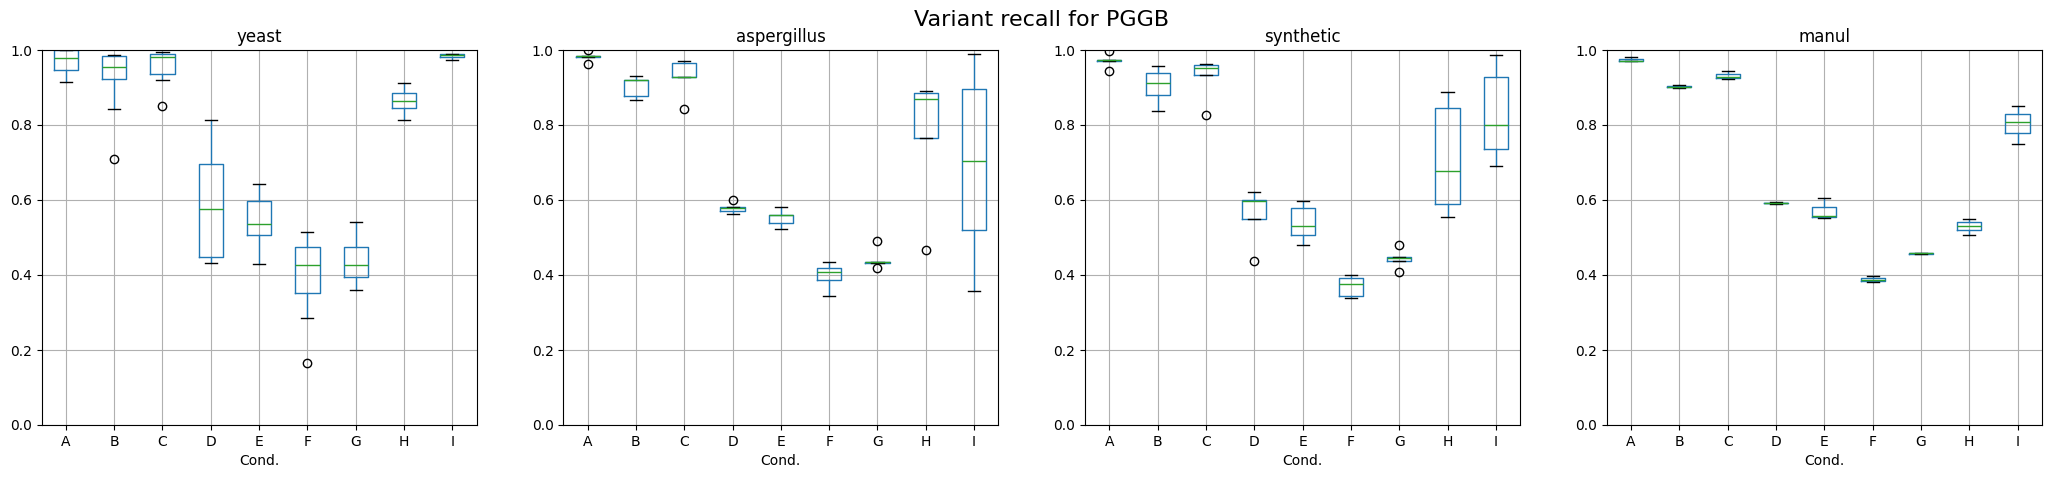

In [29]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="P_var_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
    if label_cond == 'manul':
        print(label_cond)
        result = cl.groupby(['Cond.'], as_index=False).agg(
                                {'P_var_pggb':['mean','std']})
        print(result)
fig.suptitle('Variant precision for PGGB', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="R_var_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
    if label_cond == 'manul':
        print(label_cond)
        result = cl.groupby(['Cond.'], as_index=False).agg(
                            {'R_var_pggb':['mean','std']})
        print(result)
fig.suptitle('Variant recall for PGGB', fontsize=16)

Text(0.5, 0.98, 'Précision et rappel des variants (scénario insertions/délétions)')

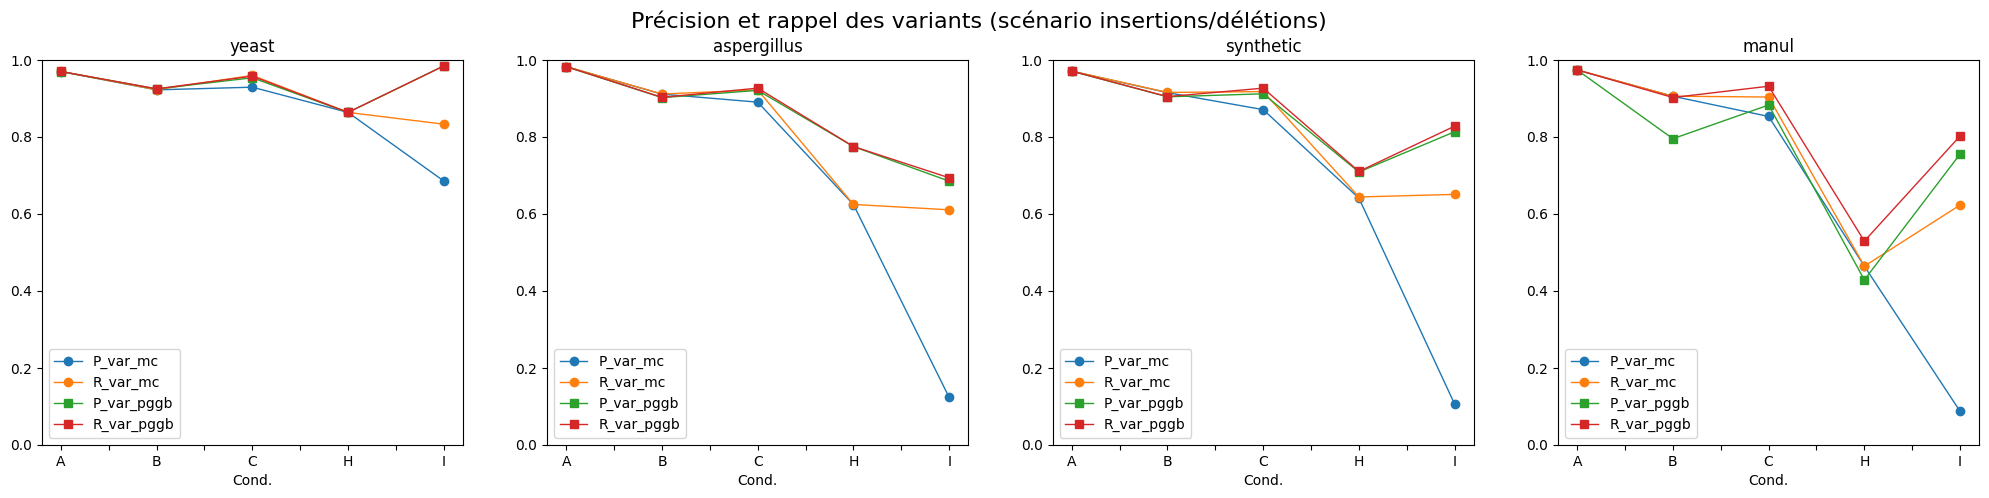

In [30]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df_indel.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").P_var_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision MC",marker='o',linewidth=1)
    cl.groupby("Cond.").R_var_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall MC",marker='o',linewidth=1)
    cl.groupby("Cond.").P_var_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision PGGB",marker='s',linewidth=1)
    cl.groupby("Cond.").R_var_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Précision et rappel des variants (scénario insertions/délétions)', fontsize=16)

Text(0.5, 0.98, 'Précision et rappel des variants (Chat de Pallas)')

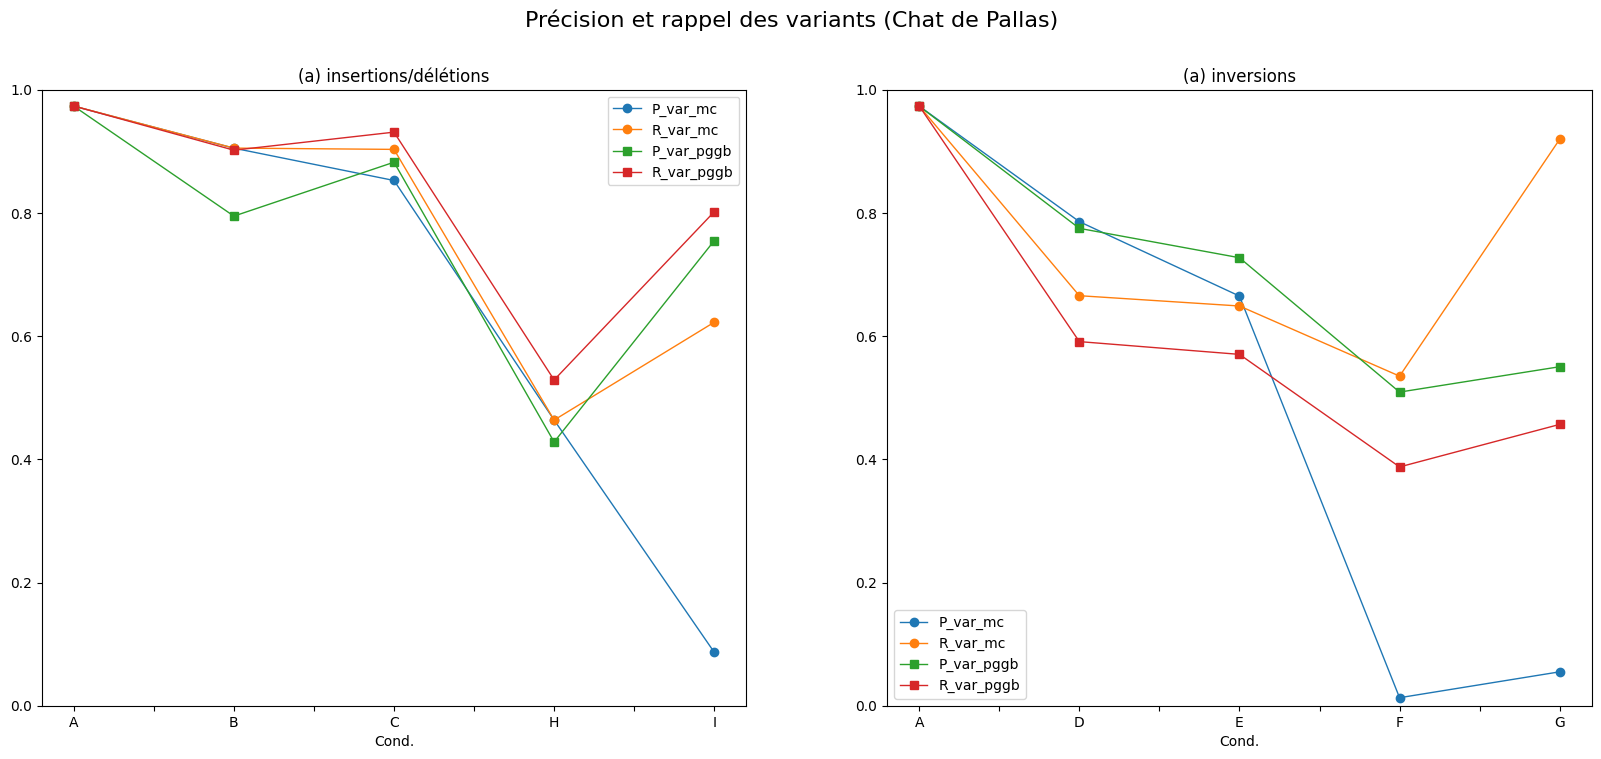

In [31]:
fig, (axs,axd) = plt.subplots(1,2,figsize=(20,8))
for label_cond,cl in df_indel.groupby('Sp.'):
    if label_cond == 'manul':
        cl.groupby("Cond.").P_var_mc.mean().plot(ax=axs,legend="Précision MC",marker='o',linewidth=1)
        cl.groupby("Cond.").R_var_mc.mean().plot(ax=axs,legend="Recall MC",marker='o',linewidth=1)
        cl.groupby("Cond.").P_var_pggb.mean().plot(ax=axs,legend="Précision PGGB",marker='s',linewidth=1)
        cl.groupby("Cond.").R_var_pggb.mean().plot(ax=axs,legend="Recall PGGB",marker='s',linewidth=1)
        axs.set_ylim(0,1)
        axs.set_title("(a) insertions/délétions")
for label_cond,cl in df_inv.groupby('Sp.'):
    if label_cond == 'manul':
        cl.groupby("Cond.").P_var_mc.mean().plot(ax=axd,legend="Précision MC",marker='o',linewidth=1)
        cl.groupby("Cond.").R_var_mc.mean().plot(ax=axd,legend="Recall MC",marker='o',linewidth=1)
        cl.groupby("Cond.").P_var_pggb.mean().plot(ax=axd,legend="Précision PGGB",marker='s',linewidth=1)
        cl.groupby("Cond.").R_var_pggb.mean().plot(ax=axd,legend="Recall PGGB",marker='s',linewidth=1)
        axd.set_ylim(0,1)
        axd.set_title("(a) inversions")

fig.suptitle('Précision et rappel des variants (Chat de Pallas)', fontsize=16)

Text(0.5, 0.98, 'Précision et rappel des variants (scénario inversions)')

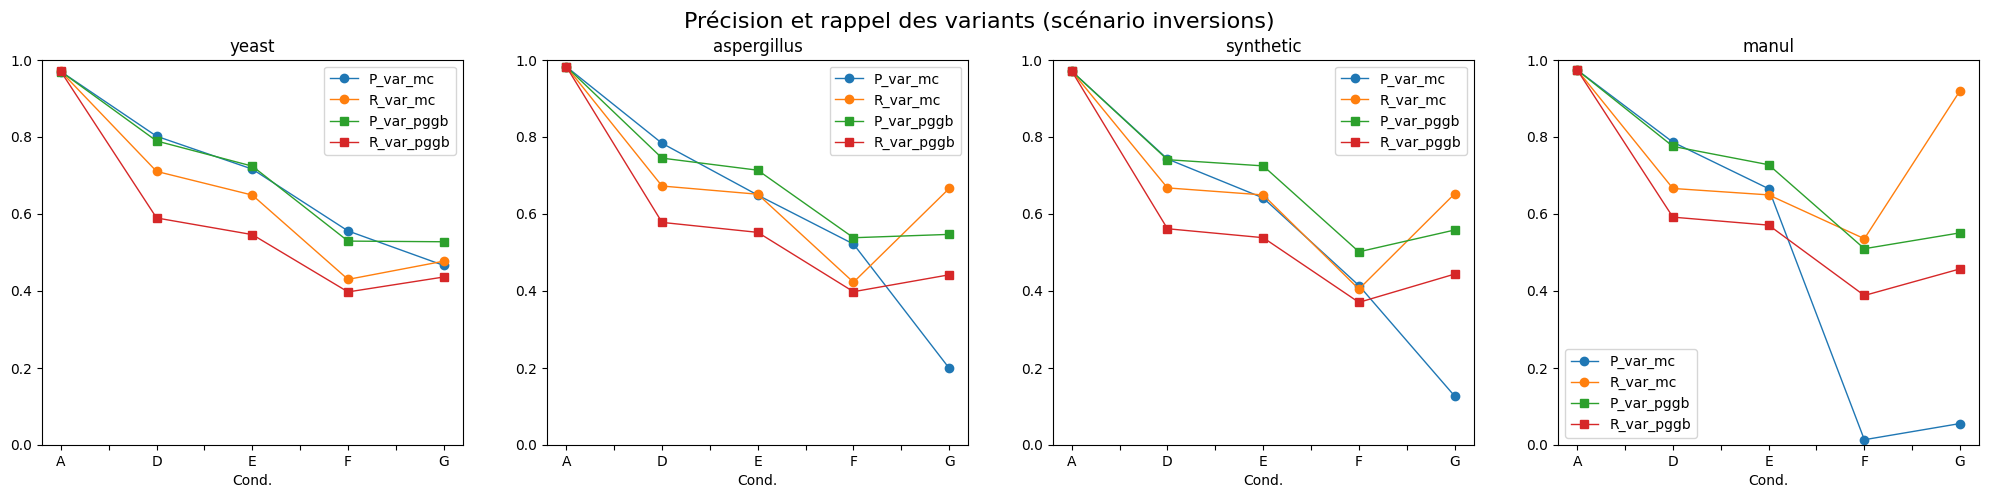

In [32]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df_inv.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").P_var_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision MC",marker='o',linewidth=1)
    cl.groupby("Cond.").R_var_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall MC",marker='o',linewidth=1)
    cl.groupby("Cond.").P_var_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision PGGB",marker='s',linewidth=1)
    cl.groupby("Cond.").R_var_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Précision et rappel des variants (scénario inversions)', fontsize=16)

Text(0.5, 0.98, '$\\mathcal{R}_b$ Part de breakpoints différents contribuant à agrandir les nœuds (MC)')

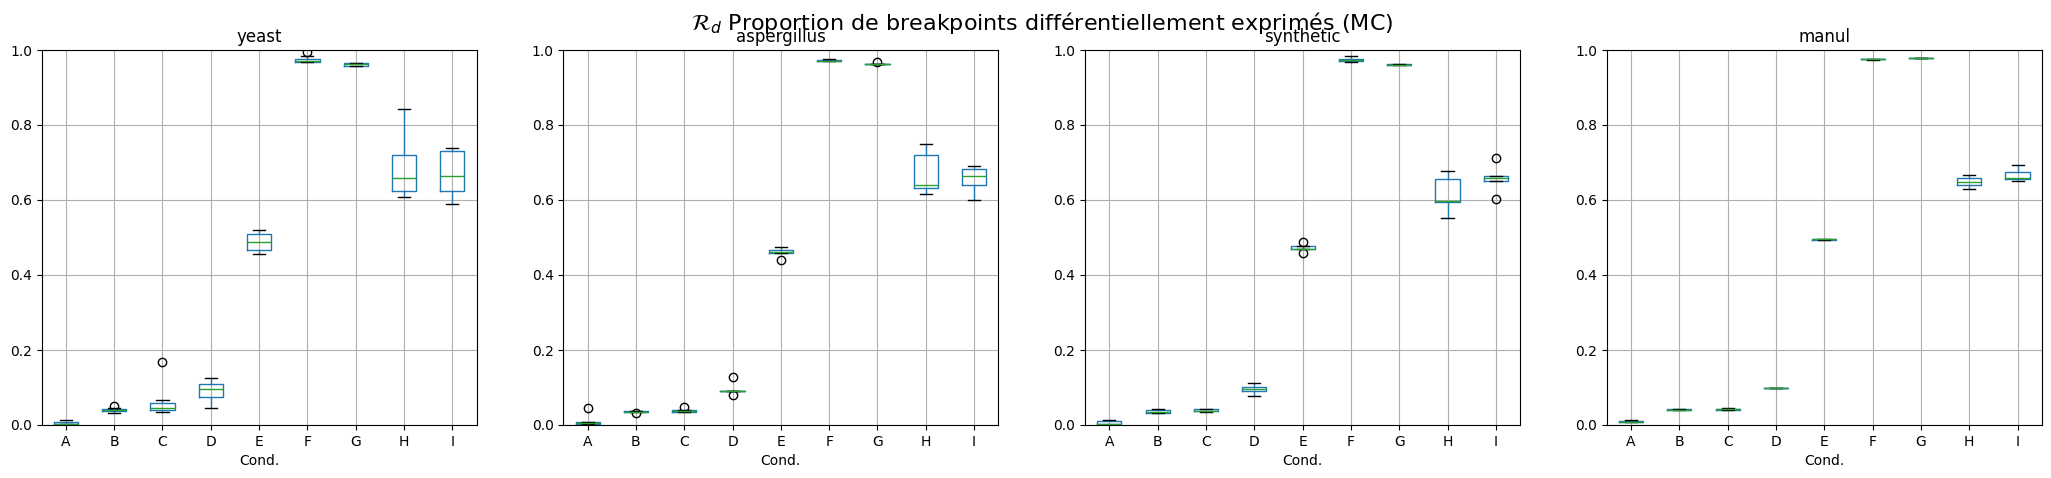

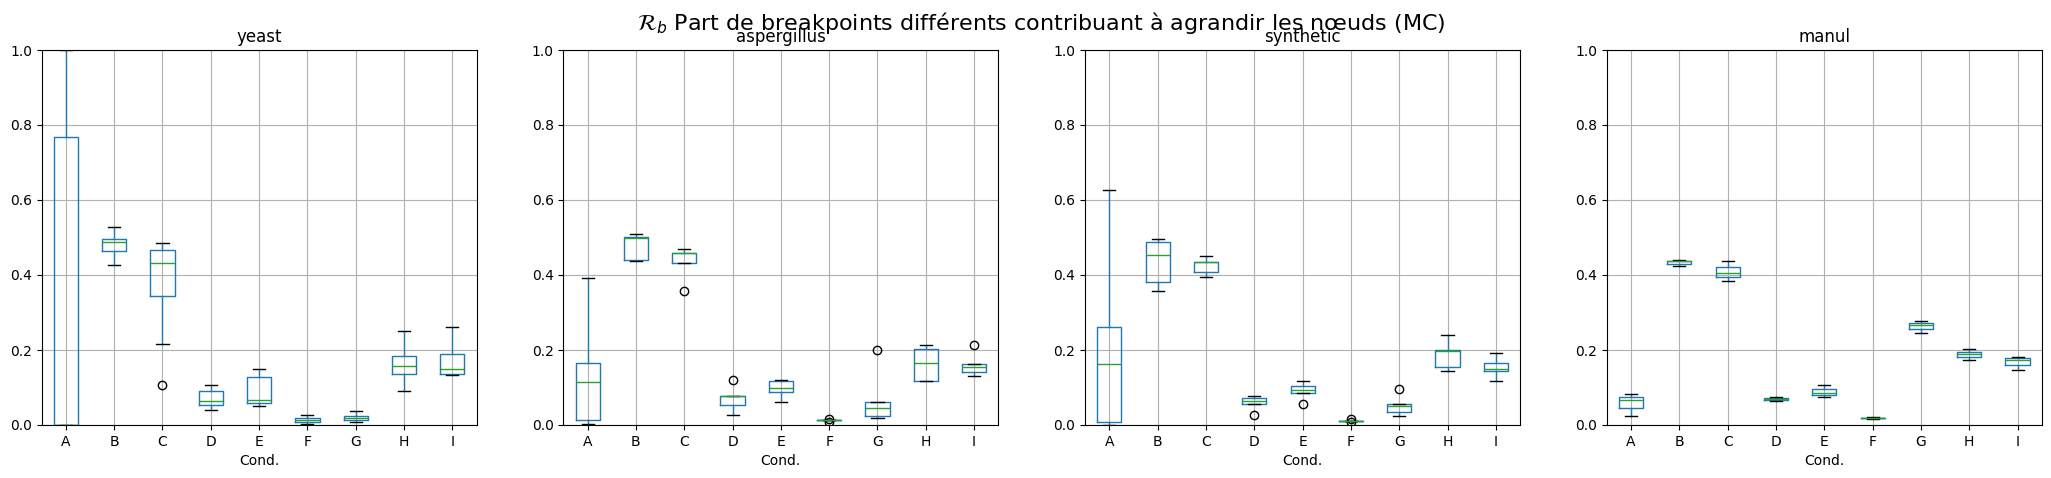

In [33]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Rd_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_d$ Proportion de breakpoints différentiellement exprimés (MC)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Rb_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_b$ Part de breakpoints différents contribuant à agrandir les nœuds (MC)', fontsize=16)

Text(0.5, 0.98, '$\\mathcal{R}_b$ Part de breakpoints différents contribuant à agrandir les nœuds (PGGB)')

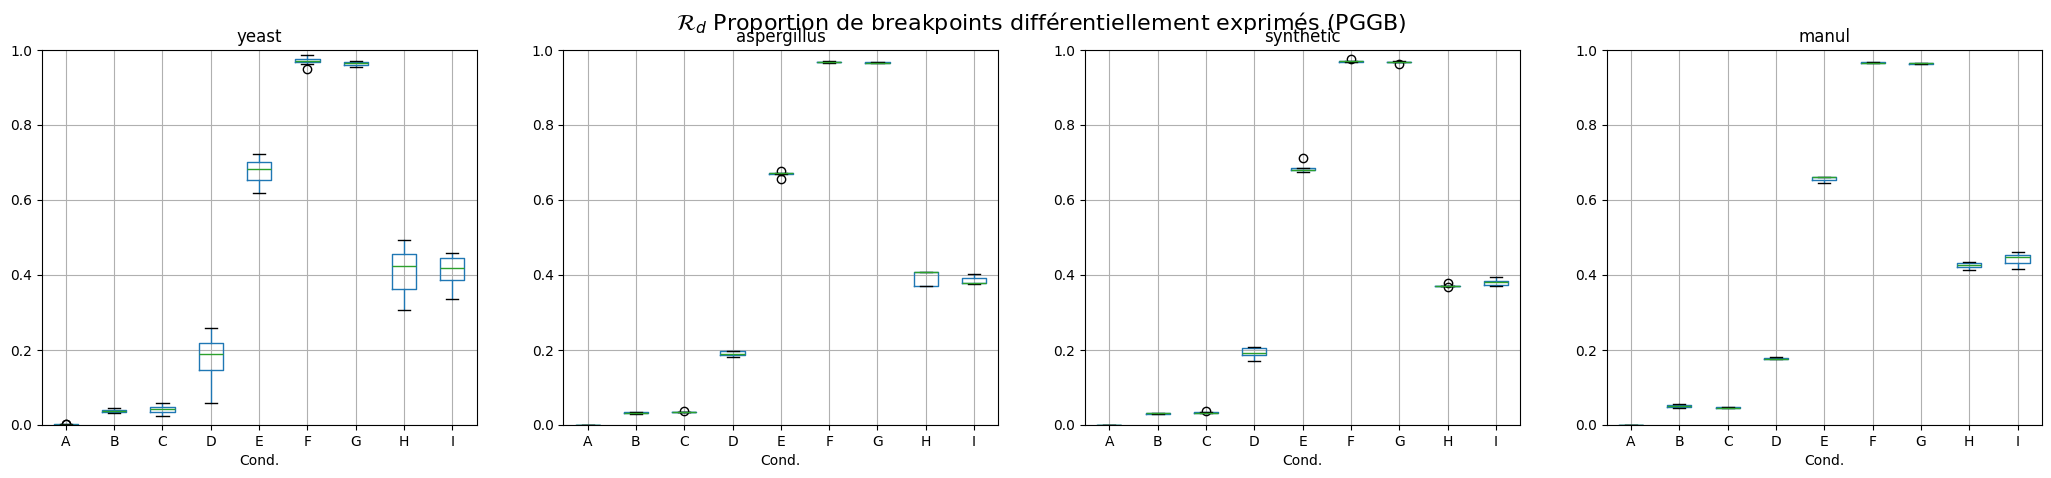

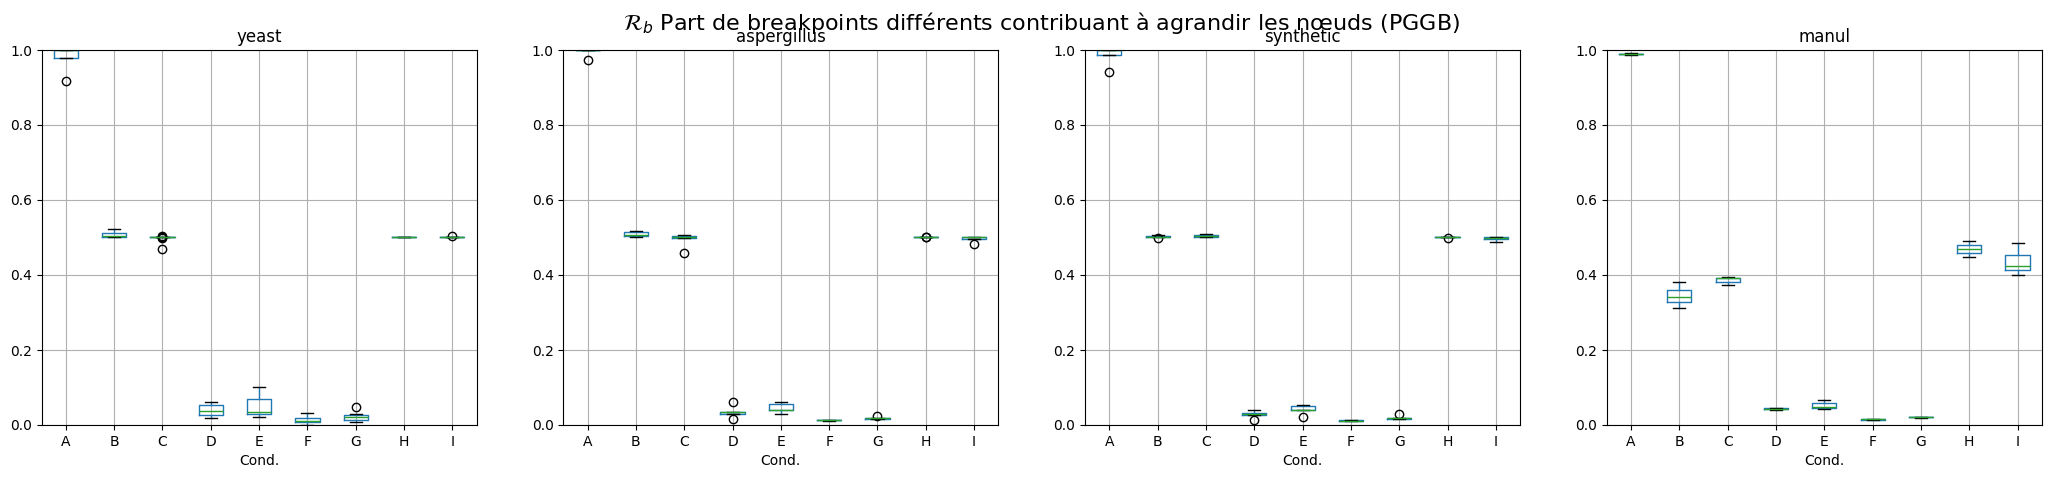

In [34]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Rd_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_d$ Proportion de breakpoints différentiellement exprimés (PGGB)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Rb_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_b$ Part de breakpoints différents contribuant à agrandir les nœuds (PGGB)', fontsize=16)

Text(0.5, 0.98, 'Ratio des points de rupture (scénario insertions/délétions)')

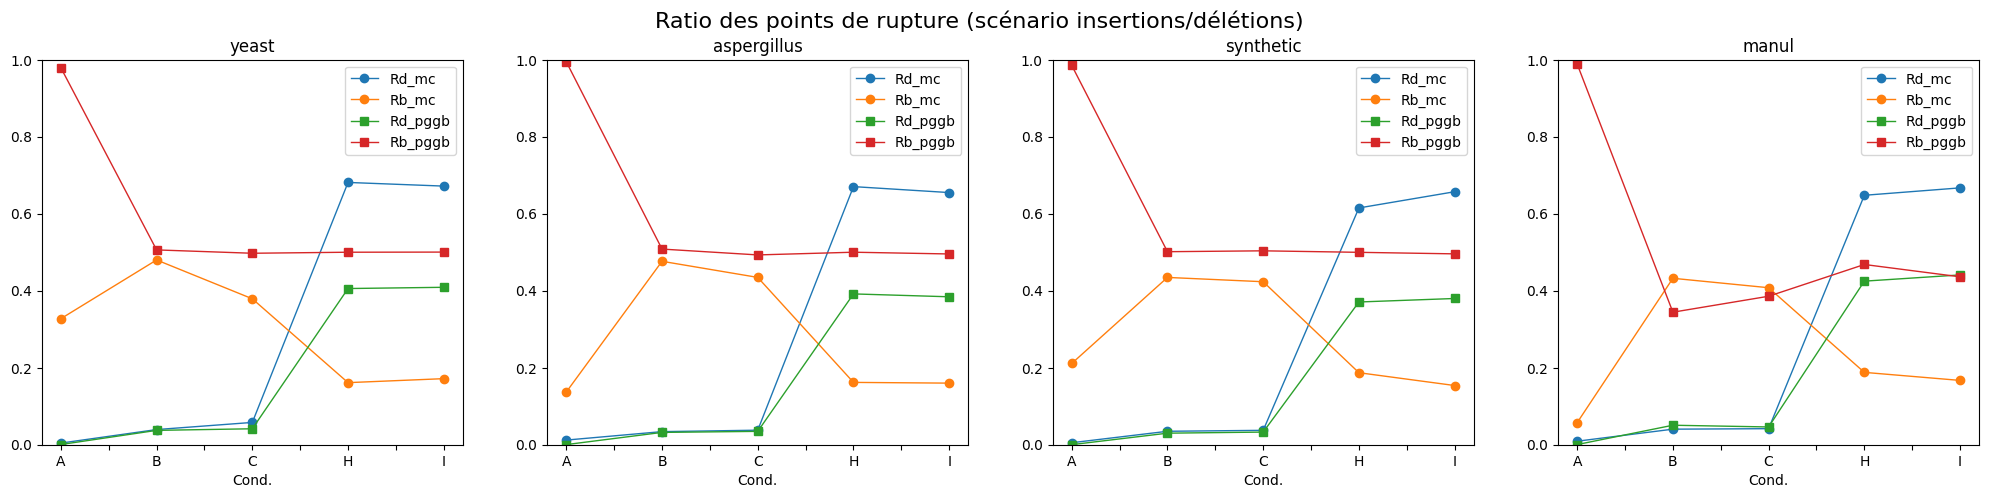

In [35]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df_indel.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").Rd_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Rd MC",marker='o',linewidth=1)
    cl.groupby("Cond.").Rb_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Rb MC",marker='o',linewidth=1)
    cl.groupby("Cond.").Rd_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Rd PGGB",marker='s',linewidth=1)
    cl.groupby("Cond.").Rb_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Rb PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Ratio des points de rupture (scénario insertions/délétions)', fontsize=16)

Text(0.5, 0.98, 'Ratio des points de rupture (scénario inversions)')

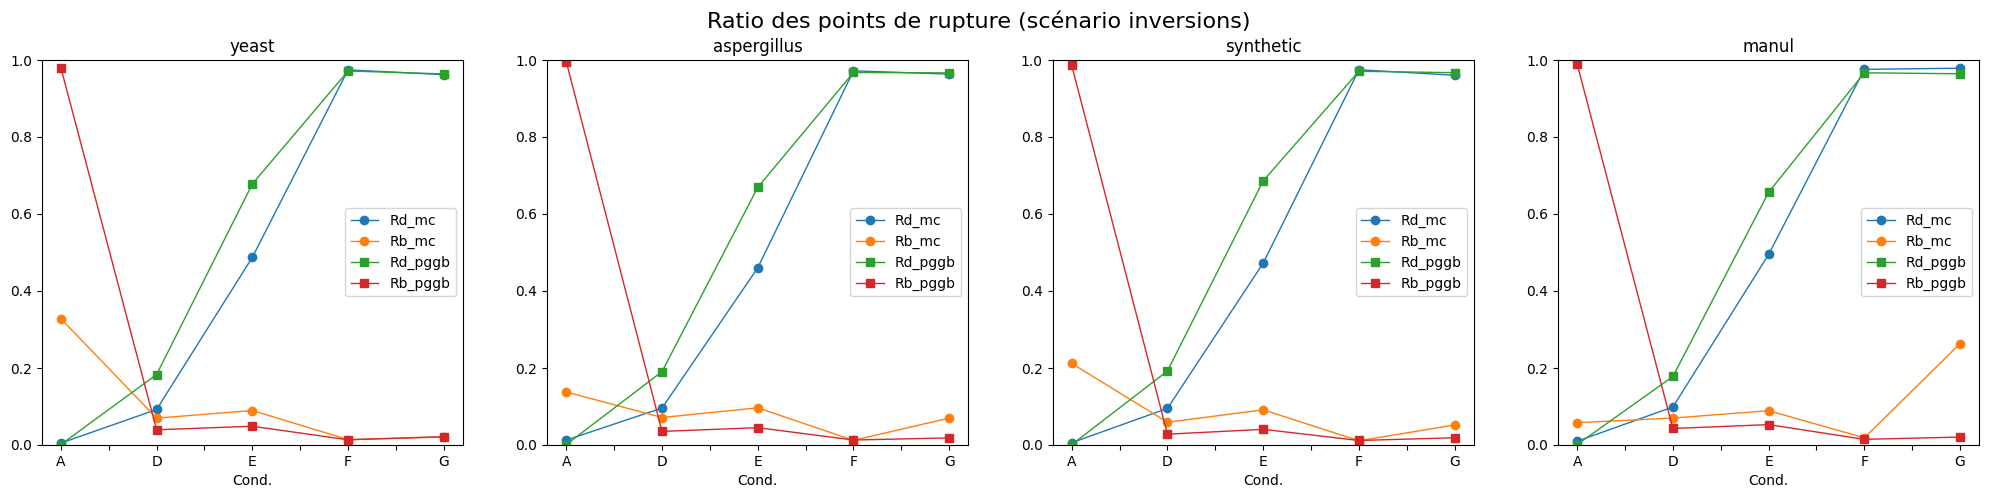

In [36]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df_inv.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").Rd_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Rd MC",marker='o',linewidth=1)
    cl.groupby("Cond.").Rb_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Rb MC",marker='o',linewidth=1)
    cl.groupby("Cond.").Rd_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Rd PGGB",marker='s',linewidth=1)
    cl.groupby("Cond.").Rb_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Rb PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Ratio des points de rupture (scénario inversions)', fontsize=16)

Le ratio de divergence $\mathcal{R}_d$ représente la part des breakpoints différentiellement exprimés. Un $\mathcal{R}_d = 1$ correspond à une paire de graphes ou aucun breakpoint n'est commun, tandis qu'un $\mathcal{R}_d = 0$ correspond à une paire de graphe ou tous les breakpoints sont communs.

\begin{equation}
    \mathcal{R}_d = \frac{M+S}{B}
\end{equation}

Les comparaisons de graphe réalisées avec rs-pancat-compare sont orientées. Si elles sont effectuées dans le sens $\mathcal{G}_A \rightarrow \mathcal{G}_B$, un merge correspond à la fusion de deux segments de $\mathcal{G}_B$ en un segment de $\mathcal{G}_A$, et un split à la division d'un segment de $\mathcal{G}_B$ en deux segments de $\mathcal{G}_A$. N'avoir que des splits signifie que $\mathcal{G}_B$ possède moins de breakpoints que $\mathcal{G}_A$ (et réciproquement pour les merges). 

\begin{equation}
    \mathcal{R}_b = \frac{S}{M+S}
\end{equation}

Le ratio $\mathcal{R}_b$ représente alors la part des breakpoints perdus par $\mathcal{G}_B$. Un $\mathcal{R}_b = 1$ signifie que tous les breakpoints différentiellement exprimés participent à former des noeuds de plus grande taille dans $\mathcal{G}_B$, alors que un $\mathcal{R}_b = 0$ donne l'information que les noeuds formés prennent une taille plus petite dans $\mathcal{G}_B$. Cette mesure est en relation avec la différence de taille moyenne des noeuds ($\Delta\mathcal{\mu}(\mathcal{V})$) entre les deux graphes.

Text(0.5, 0.98, 'Différence de taille moyenne des nœuds (PGGB)')

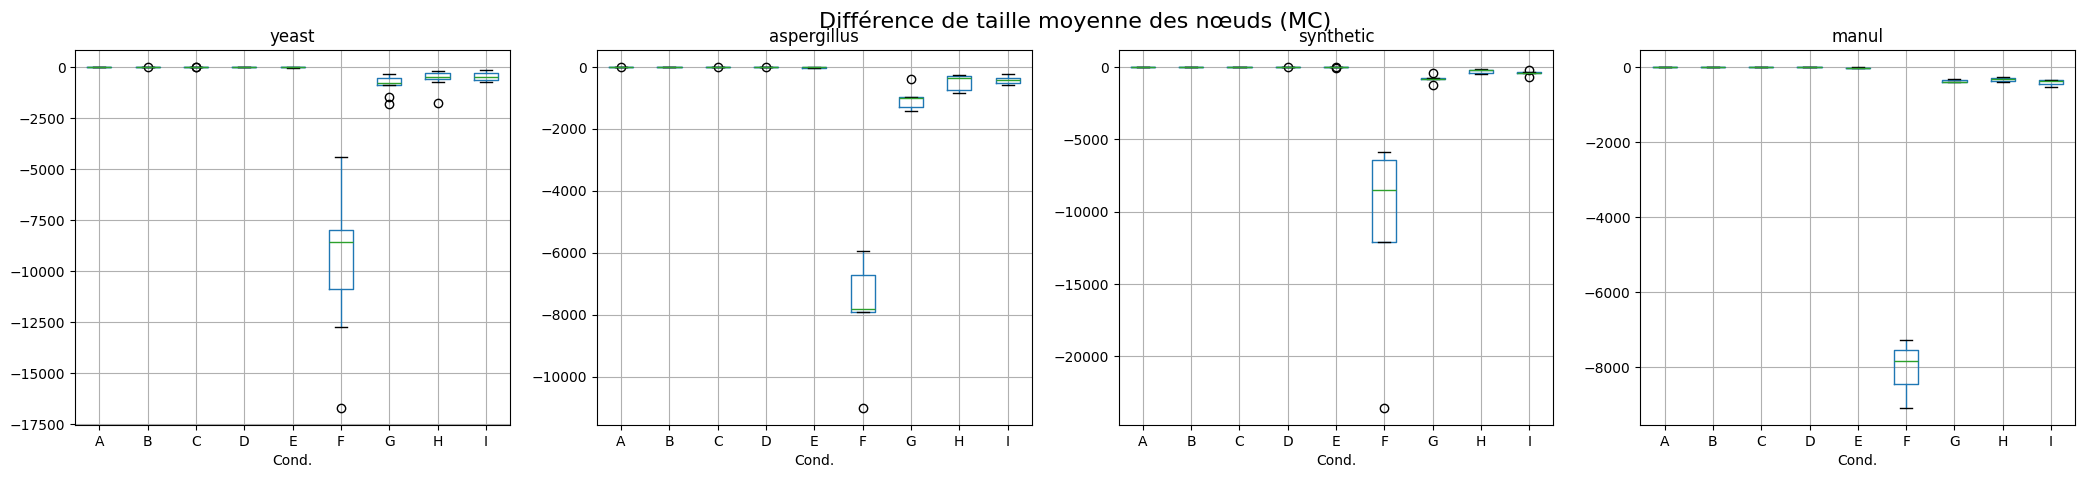

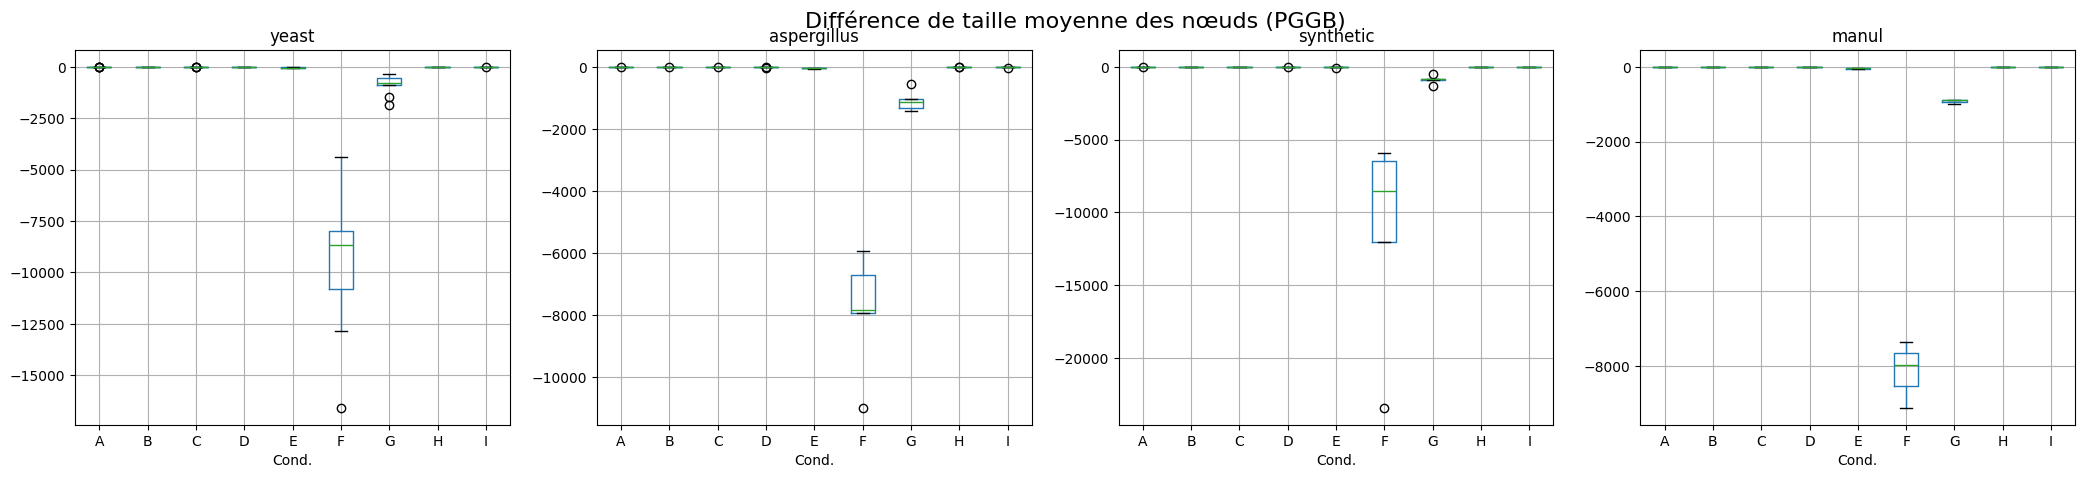

In [37]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="∆µ_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
fig.suptitle('Différence de taille moyenne des nœuds (MC)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="∆µ_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
fig.suptitle('Différence de taille moyenne des nœuds (PGGB)', fontsize=16)

manul
  Cond. P_edit_mc          
             mean       std
0     A  0.991319  0.004124
1     B  0.976660  0.000872
2     C  0.974824  0.002766
3     D  0.908154  0.000382
4     E  0.528951  0.005263
5     F  0.025465  0.001176
6     G  0.029618  0.001817
7     H  0.400968  0.024349
8     I  0.374676  0.029322
manul
  Cond. R_edit_mc          
             mean       std
0     A  0.999552  0.000112
1     B  0.982135  0.000086
2     C  0.982610  0.000024
3     D  0.992529  0.000647
4     E  0.920612  0.012526
5     F  0.589068  0.017035
6     G  0.078982  0.005343
7     H  0.743325  0.001111
8     I  0.749731  0.001904


Text(0.5, 0.98, 'Edit recall for MC')

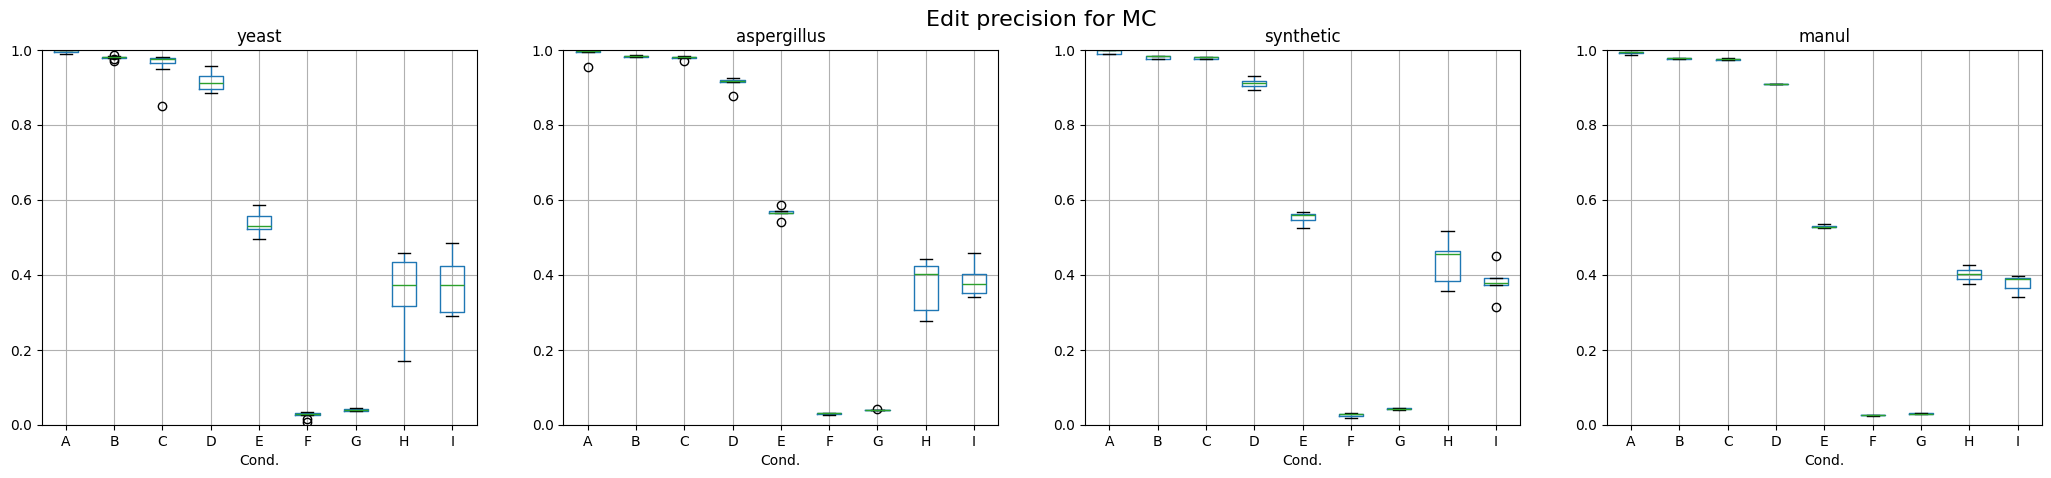

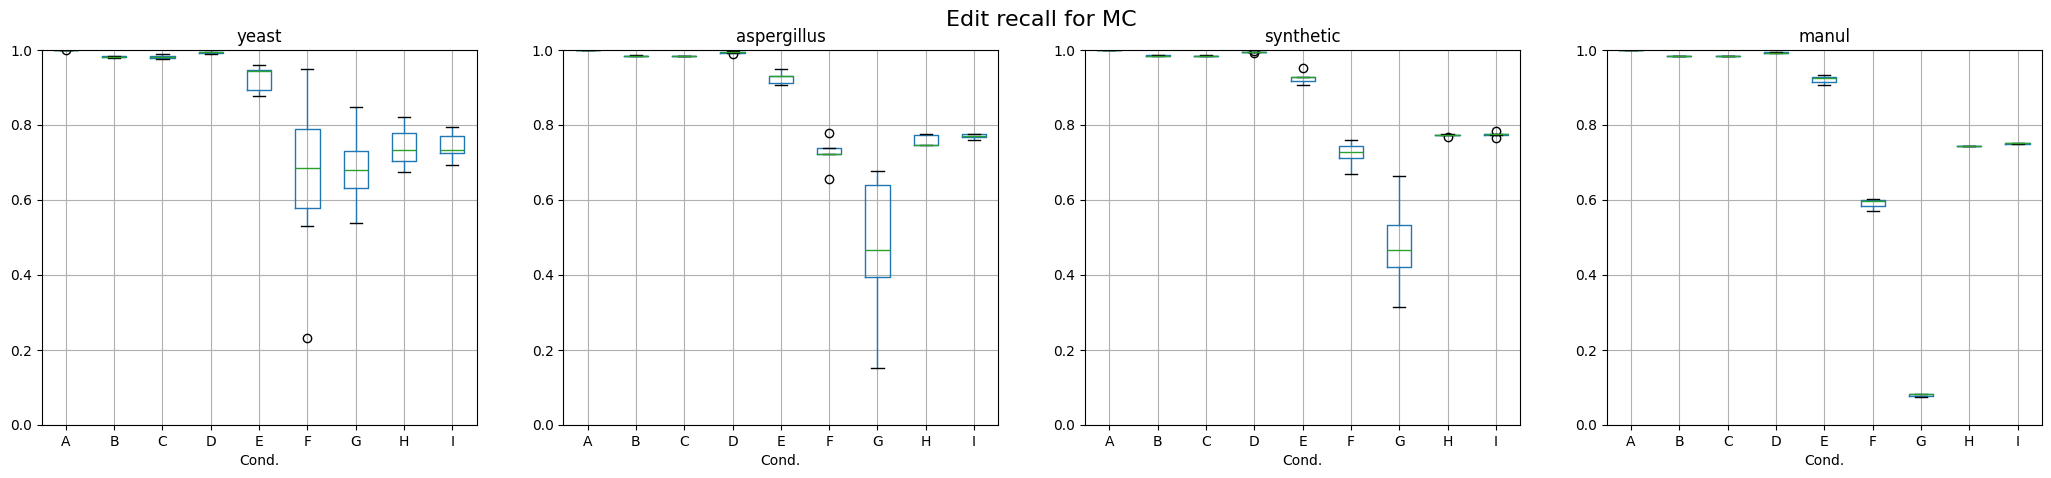

In [38]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="P_edit_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
    if label_cond == 'manul':
        print(label_cond)
        result = cl.groupby(['Cond.'], as_index=False).agg(
                        {'P_edit_mc':['mean','std']})
        print(result)
fig.suptitle('Edit precision for MC', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):

    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    bp = cl.boxplot(column="R_edit_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
    if label_cond == 'manul':
        print(label_cond)
        result = cl.groupby(['Cond.'], as_index=False).agg(
                        {'R_edit_mc':['mean','std']})
        print(result)
fig.suptitle('Edit recall for MC', fontsize=16)

manul
  Cond. P_edit_pggb          
               mean       std
0     A    0.999995  0.000001
1     B    0.966109  0.005034
2     C    0.971129  0.001289
3     D    0.828970  0.003362
4     E    0.356658  0.011552
5     F    0.034466  0.000495
6     G    0.037195  0.000799
7     H    0.717849  0.017109
8     I    0.691783  0.035317
manul
  Cond. R_edit_pggb          
               mean       std
0     A    0.999576  0.000108
1     B    0.982091  0.000119
2     C    0.981695  0.000060
3     D    0.990982  0.000940
4     E    0.910156  0.015650
5     F    0.715480  0.001245
6     G    0.656264  0.014612
7     H    0.743197  0.001086
8     I    0.744664  0.001308


Text(0.5, 0.98, 'Edit recall for PGGB')

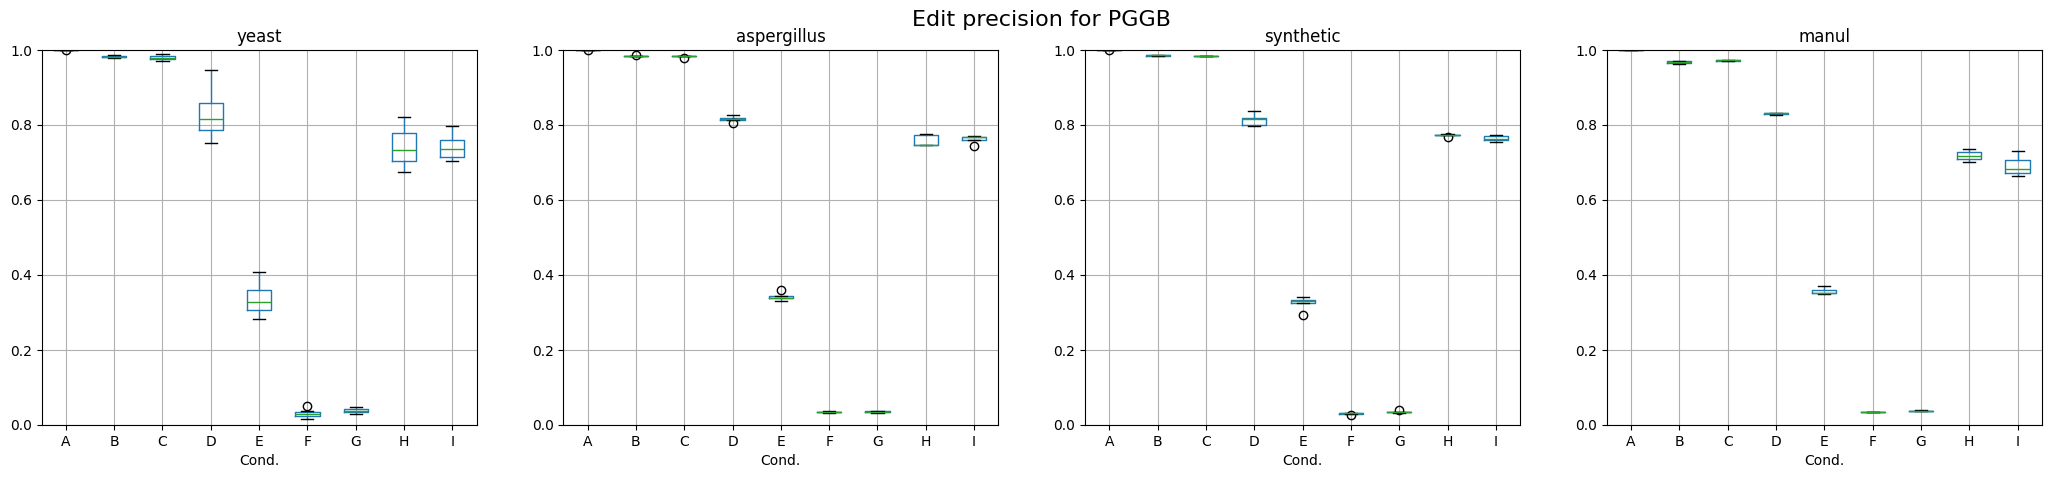

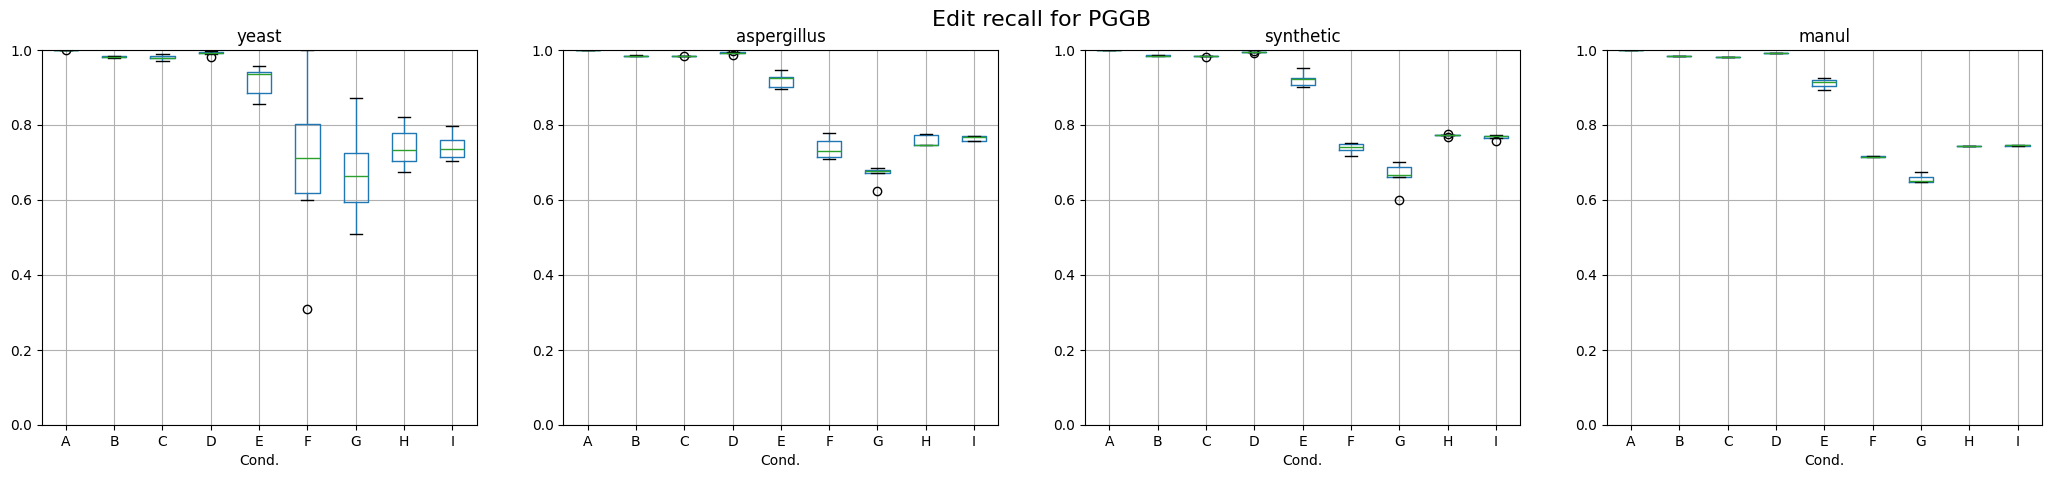

In [39]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="P_edit_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
    if label_cond == 'manul':
        print(label_cond)
        result = cl.groupby(['Cond.'], as_index=False).agg(
                            {'P_edit_pggb':['mean','std']})
        print(result)
fig.suptitle('Edit precision for PGGB', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="R_edit_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
    if label_cond == 'manul':
        print(label_cond)
        result = cl.groupby(['Cond.'], as_index=False).agg(
                            {'R_edit_pggb':['mean','std']})
        print(result)
fig.suptitle('Edit recall for PGGB', fontsize=16)

Text(0.5, 0.98, 'Précision et rappel des points de rupture (scénarios insertions/délétions)')

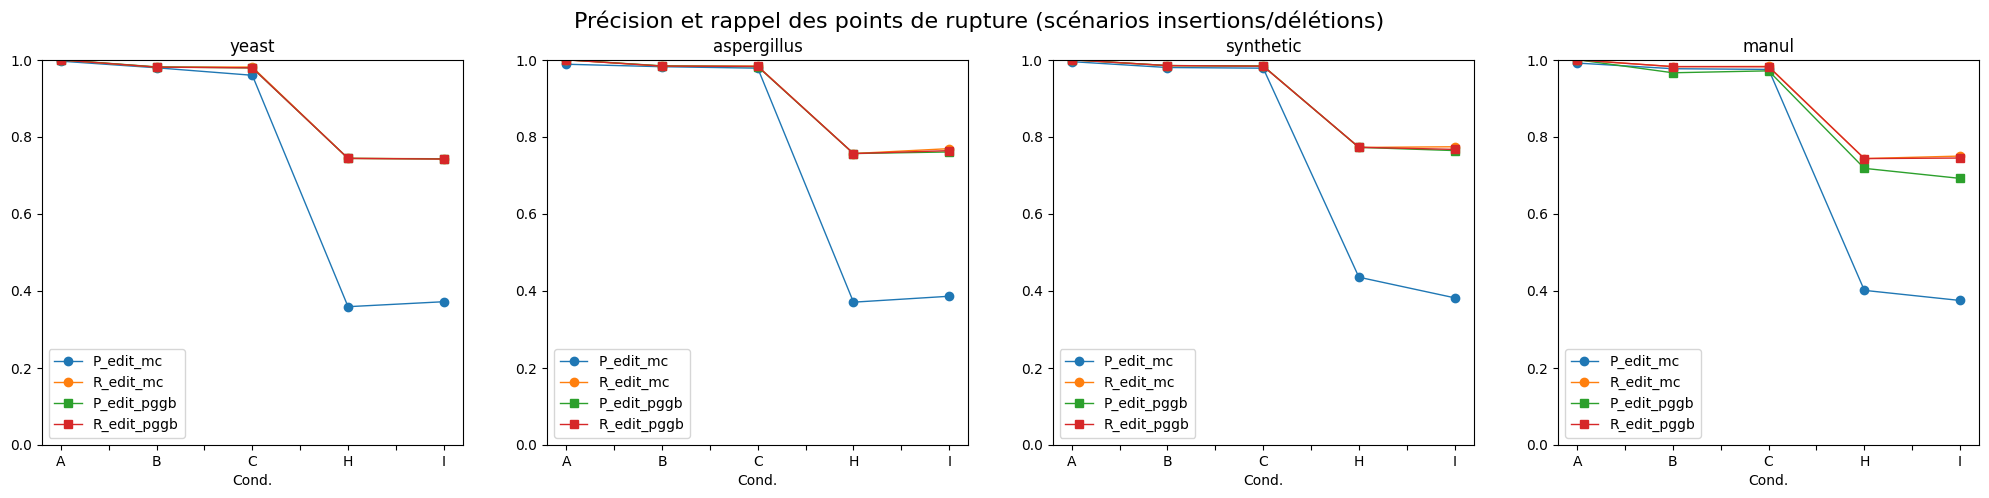

In [40]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df_indel.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").P_edit_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision MC",marker='o',linewidth=1)
    cl.groupby("Cond.").R_edit_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall MC",marker='o',linewidth=1)
    cl.groupby("Cond.").P_edit_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision PGGB",marker='s',linewidth=1)
    cl.groupby("Cond.").R_edit_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Précision et rappel des points de rupture (scénarios insertions/délétions)', fontsize=16)

Text(0.5, 0.98, 'Précision et rappel des points de rupture (scénarios inversions)')

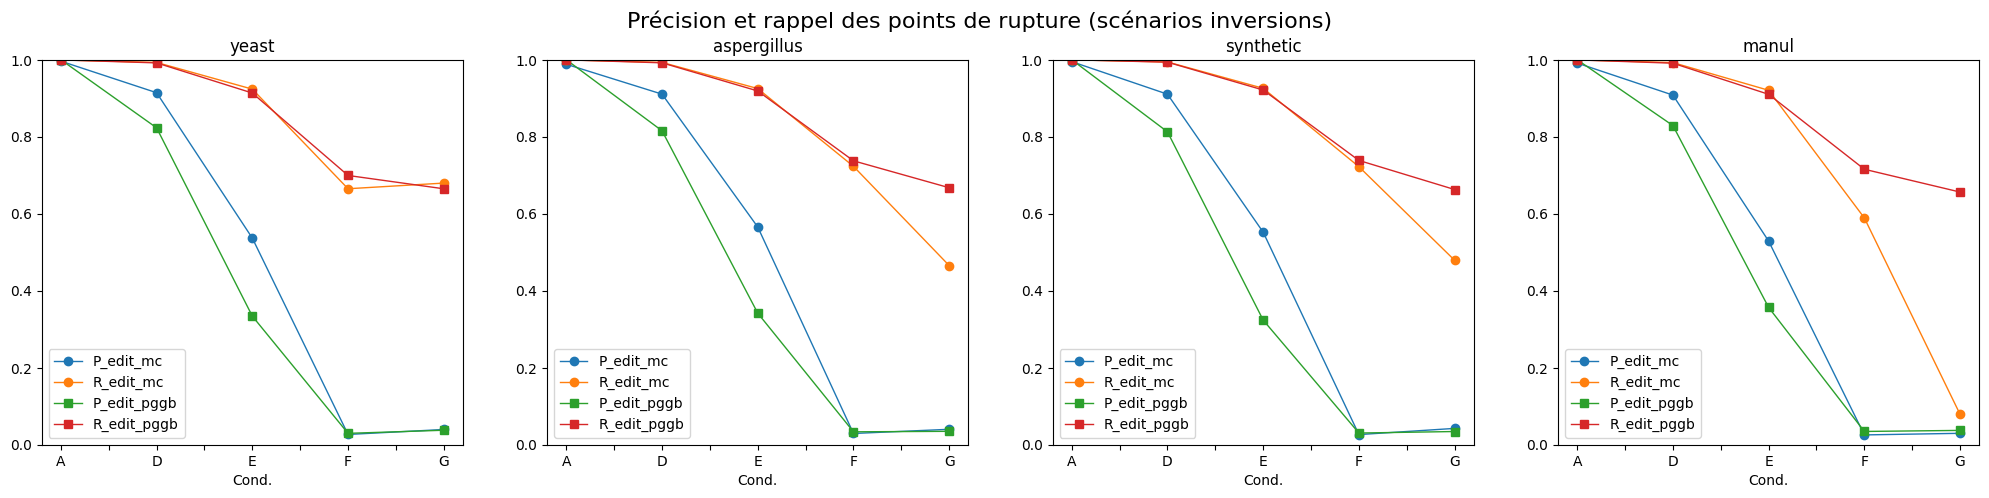

In [41]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df_inv.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").P_edit_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision MC",marker='o',linewidth=1)
    cl.groupby("Cond.").R_edit_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall MC",marker='o',linewidth=1)
    cl.groupby("Cond.").P_edit_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision PGGB",marker='s',linewidth=1)
    cl.groupby("Cond.").R_edit_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Précision et rappel des points de rupture (scénarios inversions)', fontsize=16)

Text(0.5, 0.98, 'Précision et rappel des éditions (Chat de Pallas)')

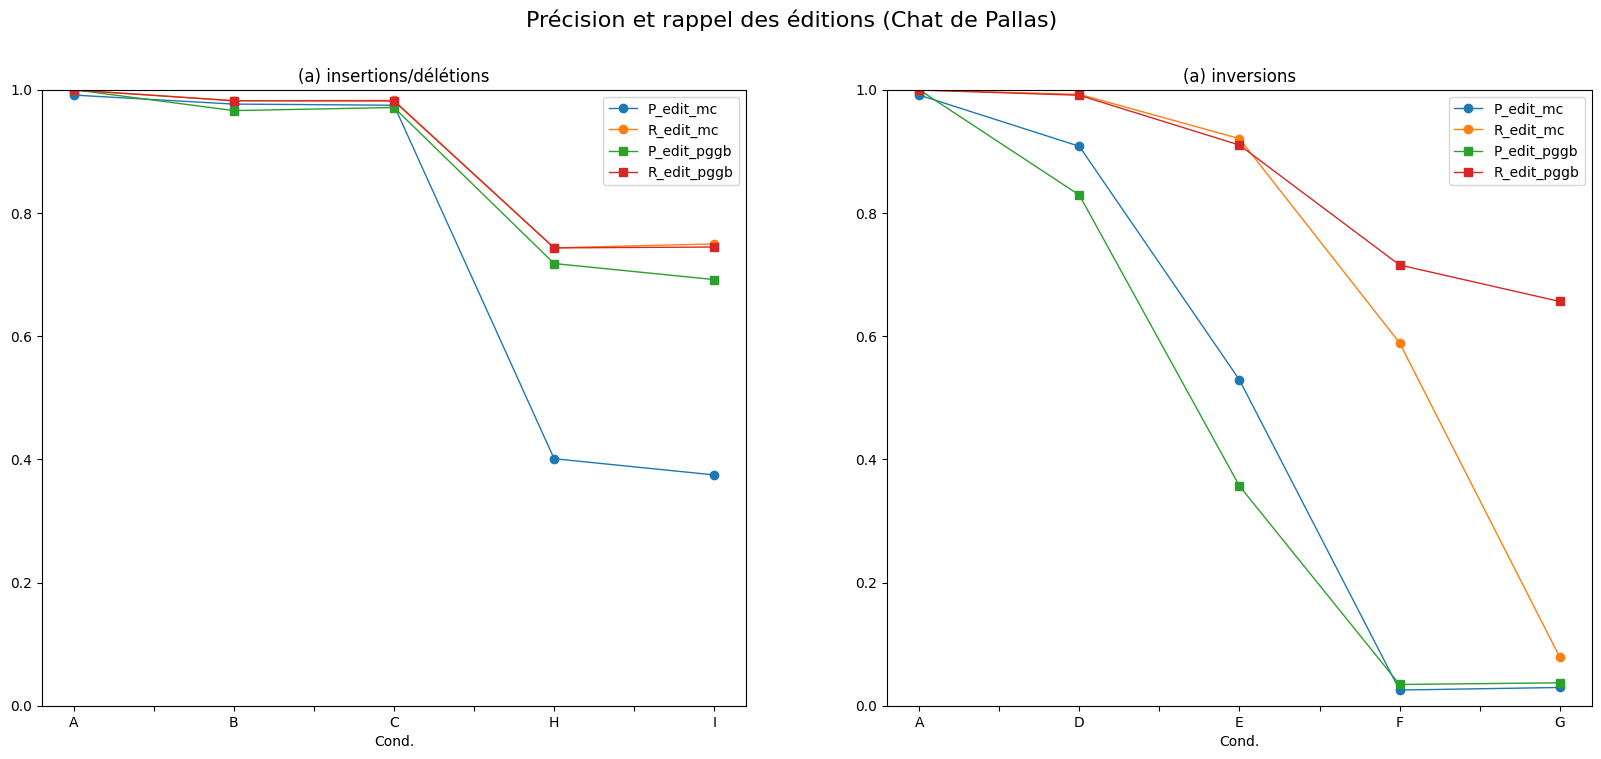

In [42]:
fig, (axs,axd) = plt.subplots(1,2,figsize=(20,8))
for label_cond,cl in df_indel.groupby('Sp.'):
    if label_cond == 'manul':
        cl.groupby("Cond.").P_edit_mc.mean().plot(ax=axs,legend="Précision MC",marker='o',linewidth=1)
        cl.groupby("Cond.").R_edit_mc.mean().plot(ax=axs,legend="Recall MC",marker='o',linewidth=1)
        cl.groupby("Cond.").P_edit_pggb.mean().plot(ax=axs,legend="Précision PGGB",marker='s',linewidth=1)
        cl.groupby("Cond.").R_edit_pggb.mean().plot(ax=axs,legend="Recall PGGB",marker='s',linewidth=1)
        axs.set_ylim(0,1)
        axs.set_title("(a) insertions/délétions")
for label_cond,cl in df_inv.groupby('Sp.'):
    if label_cond == 'manul':
        cl.groupby("Cond.").P_edit_mc.mean().plot(ax=axd,legend="Précision MC",marker='o',linewidth=1)
        cl.groupby("Cond.").R_edit_mc.mean().plot(ax=axd,legend="Recall MC",marker='o',linewidth=1)
        cl.groupby("Cond.").P_edit_pggb.mean().plot(ax=axd,legend="Précision PGGB",marker='s',linewidth=1)
        cl.groupby("Cond.").R_edit_pggb.mean().plot(ax=axd,legend="Recall PGGB",marker='s',linewidth=1)
        axd.set_ylim(0,1)
        axd.set_title("(a) inversions")

fig.suptitle('Précision et rappel des éditions (Chat de Pallas)', fontsize=16)

Text(0.5, 0.98, 'Précision et rappel des points de rupture')

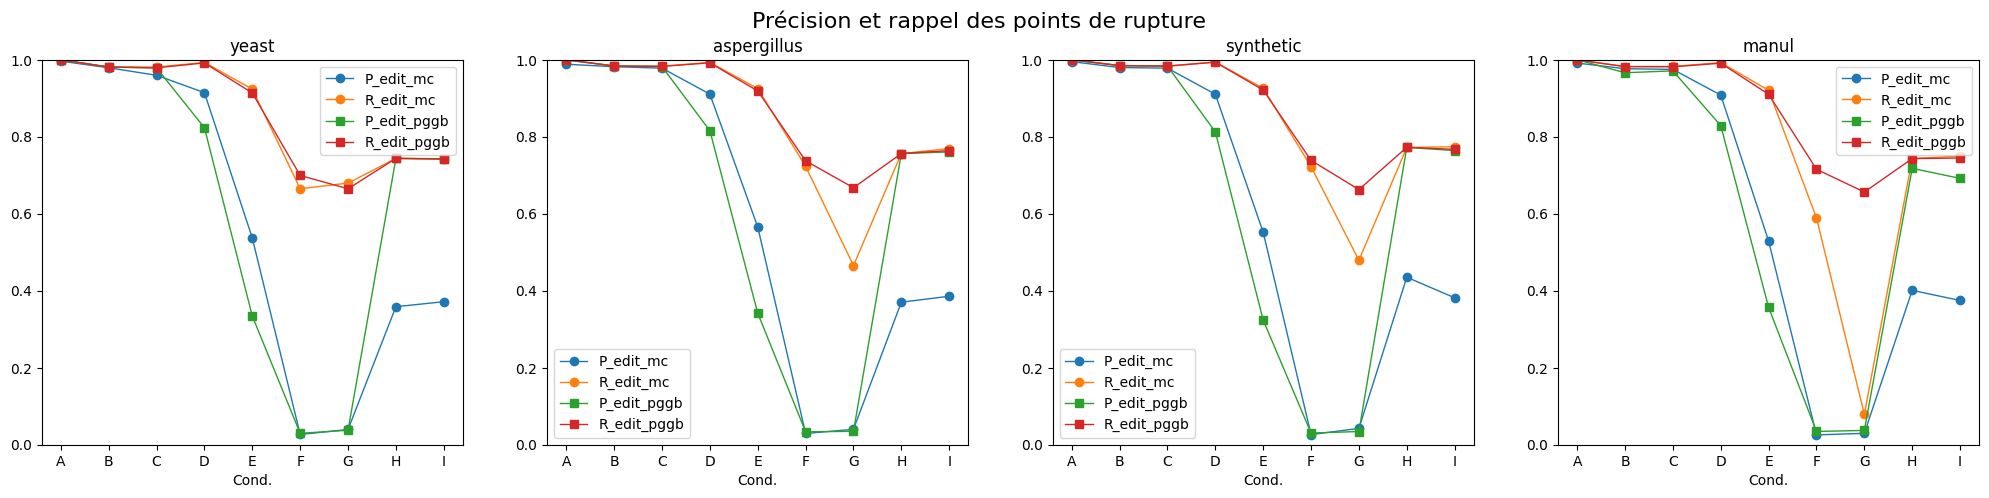

In [43]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").P_edit_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision MC",marker='o',linewidth=1)
    cl.groupby("Cond.").R_edit_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall MC",marker='o',linewidth=1)
    cl.groupby("Cond.").P_edit_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Précision PGGB",marker='s',linewidth=1)
    cl.groupby("Cond.").R_edit_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="Recall PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Précision et rappel des points de rupture', fontsize=16)

In [44]:
df2:pandas.DataFrame = pandas.read_csv('patterns.csv')

df2["Rm_mc"] = df2["Pm_MC"]/(df2["Pm_MC"]+df2["Ps_MC"]+df2["Pe_MC"])
df2["Rs_mc"] = df2["Ps_MC"]/(df2["Pm_MC"]+df2["Ps_MC"]+df2["Pe_MC"])
df2["Re_mc"] = df2["Pe_MC"]/(df2["Pm_MC"]+df2["Ps_MC"]+df2["Pe_MC"])

df2["Rm_pggb"] = df2["Pm_PGGB"]/(df2["Pm_PGGB"]+df2["Ps_PGGB"]+df2["Pe_PGGB"])
df2["Rs_pggb"] = df2["Ps_PGGB"]/(df2["Pm_PGGB"]+df2["Ps_PGGB"]+df2["Pe_PGGB"])
df2["Re_pggb"] = df2["Pe_PGGB"]/(df2["Pm_PGGB"]+df2["Ps_PGGB"]+df2["Pe_PGGB"])

df2


,Sp.,Cond.,µ,Rep.,Pm_MC,Ps_MC,Pe_MC,Pm_PGGB,Ps_PGGB,Pe_PGGB,Rm_mc,Rs_mc,Re_mc,Rm_pggb,Rs_pggb,Re_pggb
0,manul,C,10000000.0,rep2,33713,7837,161228,61397,8742,169714,0.166256,0.038648,0.795096,0.255978,0.036447,0.707575
1,yeast,C,10000000.0,rep10,95,24,1100,34,34,1202,0.077933,0.019688,0.902379,0.026772,0.026772,0.946457
2,yeast,A,10000000.0,rep8,0,90,20,0,90,20,0.000000,0.818182,0.181818,0.000000,0.818182,0.181818
3,aspergillus,A,10000000.0,rep3,970,160,80,0,190,0,0.801653,0.132231,0.066116,0.000000,1.000000,0.000000
4,aspergillus,C,10000000.0,rep5,1423,464,13134,528,434,13712,0.094734,0.030890,0.874376,0.035982,0.029576,0.934442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,synthetic,A,10000000.0,rep5,40,80,30,0,90,0,0.266667,0.533333,0.200000,0.000000,1.000000,0.000000
203,synthetic,G,10000000.0,rep4,283756,3146,14566,467165,1764,10388,0.941247,0.010436,0.048317,0.974647,0.003680,0.021673
204,synthetic,C,10000000.0,rep3,2474,296,8874,200,332,9370,0.212470,0.025421,0.762109,0.020198,0.033529,0.946273
205,synthetic,F,10000000.0,rep5,84052,0,1756,82688,150,1402,0.979536,0.000000,0.020464,0.981576,0.001781,0.016643


In [45]:
df_indel_2 = df2[(df2['Cond.'] == 'A') | (df2['Cond.'] == 'B') |(df2['Cond.'] == 'C') |(df2['Cond.'] == 'H') |(df2['Cond.'] == 'I')]
df_inv_2 = df2[(df2['Cond.'] == 'A') | (df2['Cond.'] == 'D') |(df2['Cond.'] == 'E') |(df2['Cond.'] == 'F') |(df2['Cond.'] == 'G')]

Text(0.5, 0.98, '$\\mathcal{R}_\\hat{e}$ Breakpoints différentiellement exprimés décalant des nœuds (MC)')

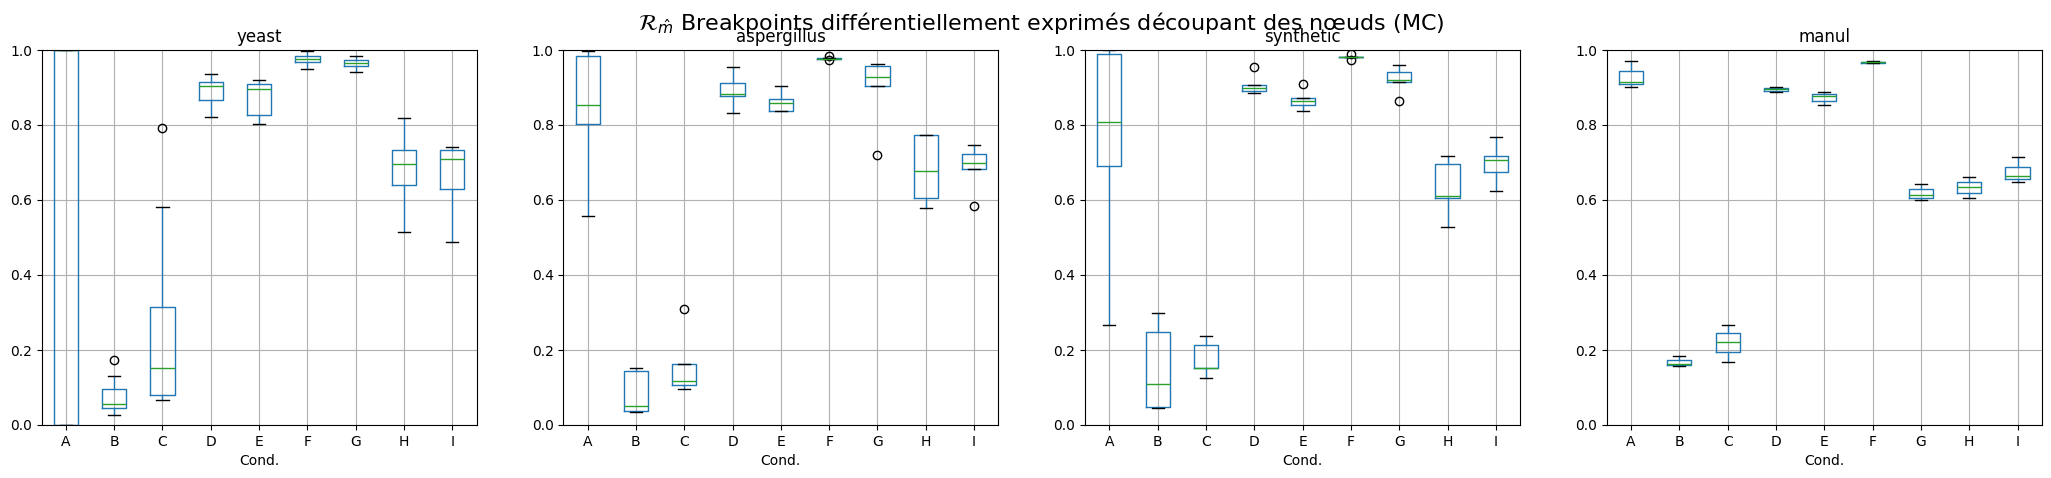

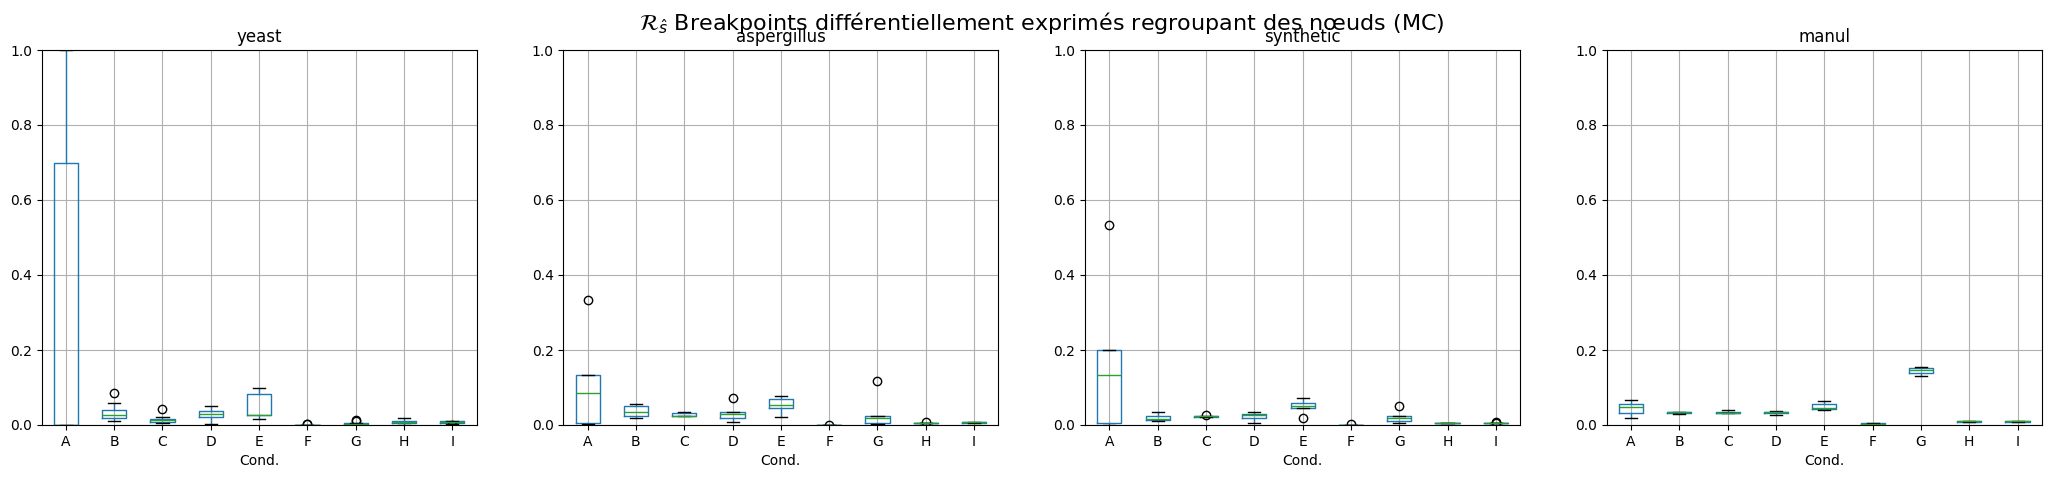

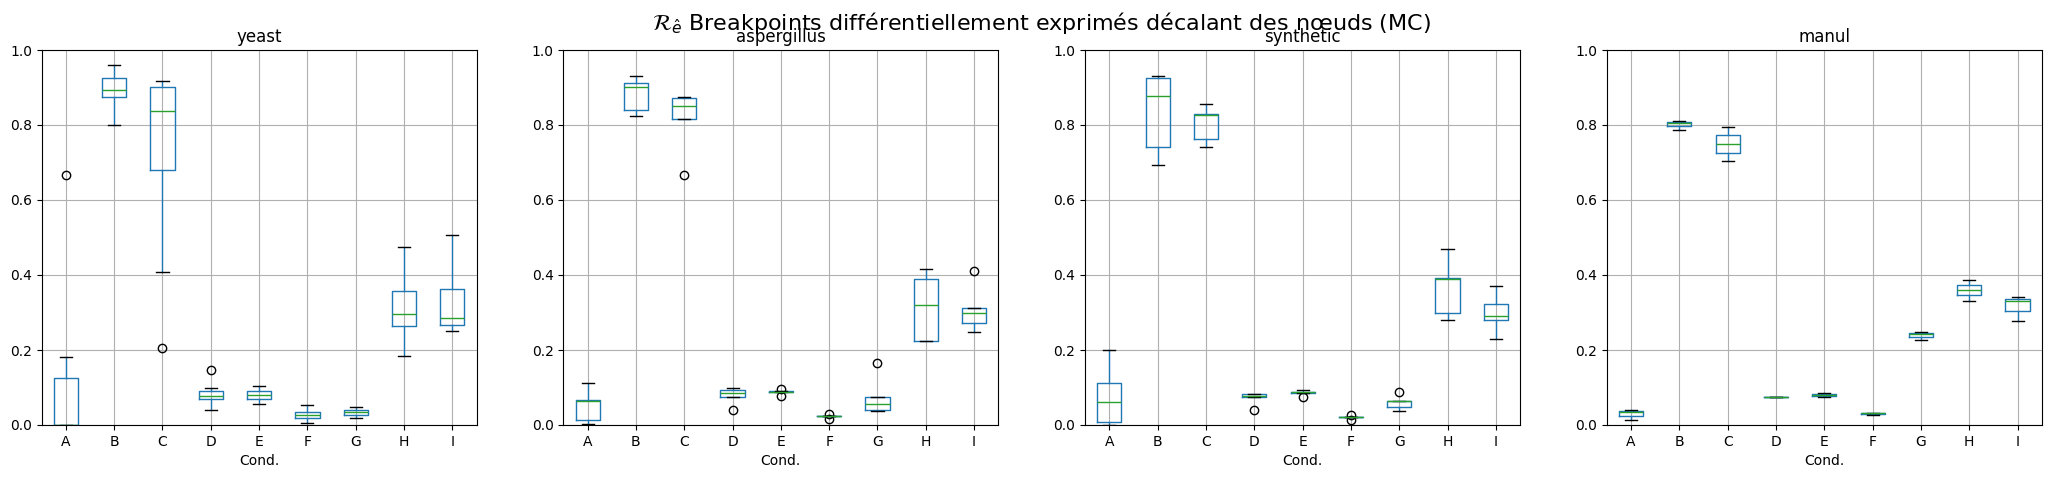

In [46]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df2.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Rm_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_\\hat{m}$ Breakpoints différentiellement exprimés découpant des nœuds (MC)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df2.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Rs_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_\\hat{s}$ Breakpoints différentiellement exprimés regroupant des nœuds (MC)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df2.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Re_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_\\hat{e}$ Breakpoints différentiellement exprimés décalant des nœuds (MC)', fontsize=16)

Text(0.5, 0.98, '$\\mathcal{R}_\\hat{e}$ Breakpoints différentiellement exprimés décalant des nœuds (PGGB)')

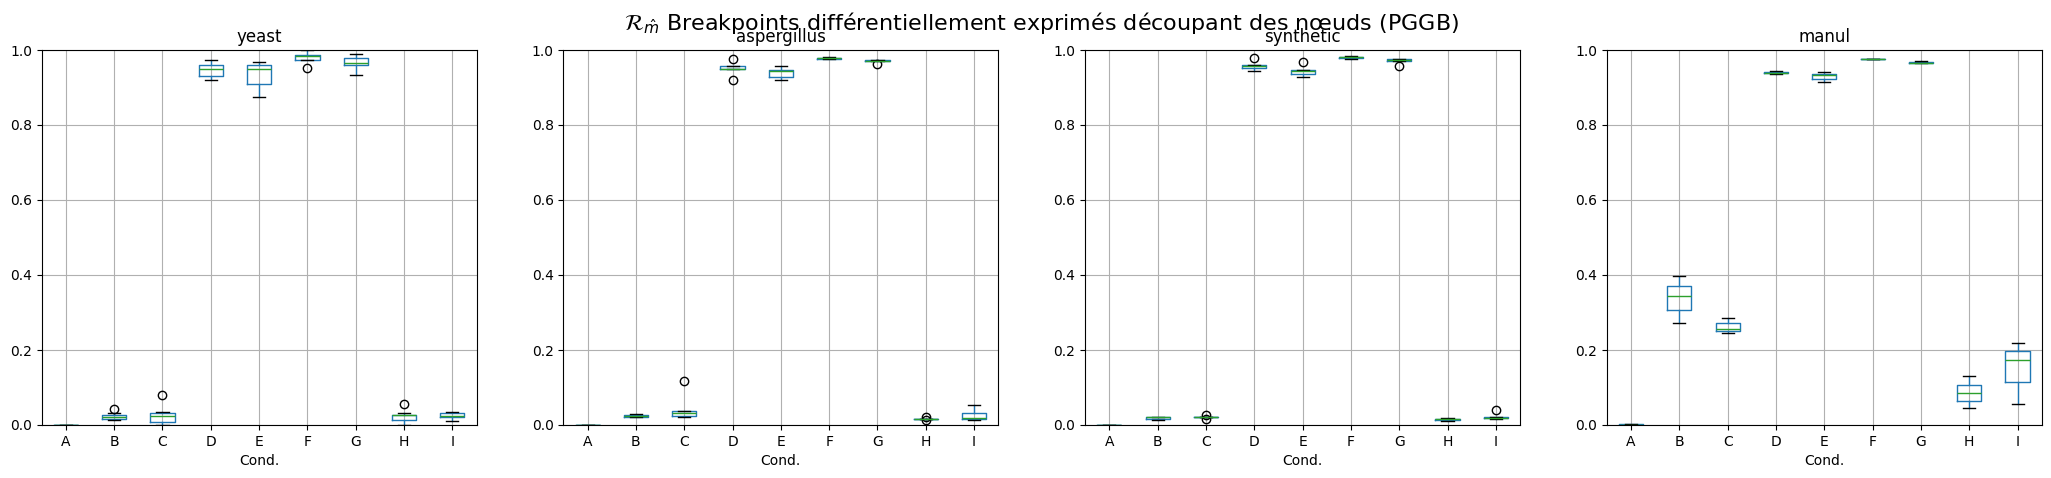

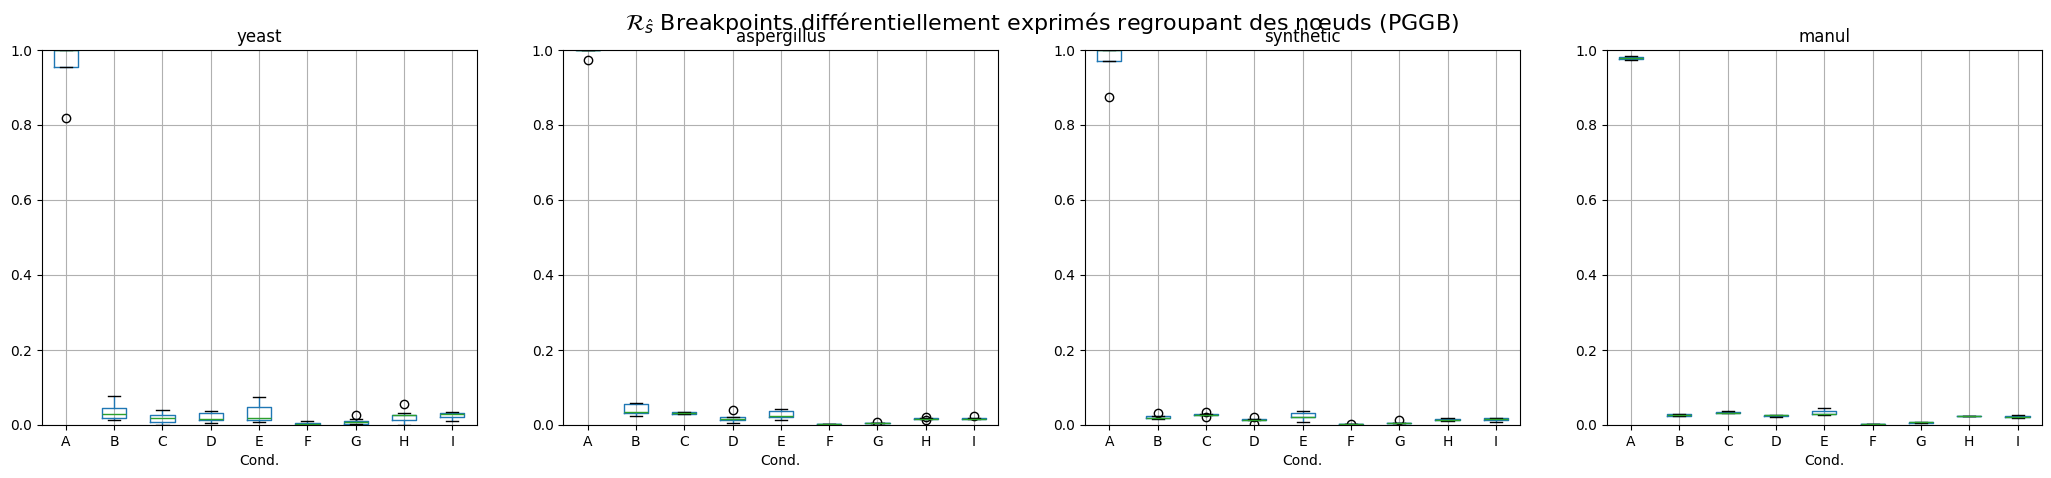

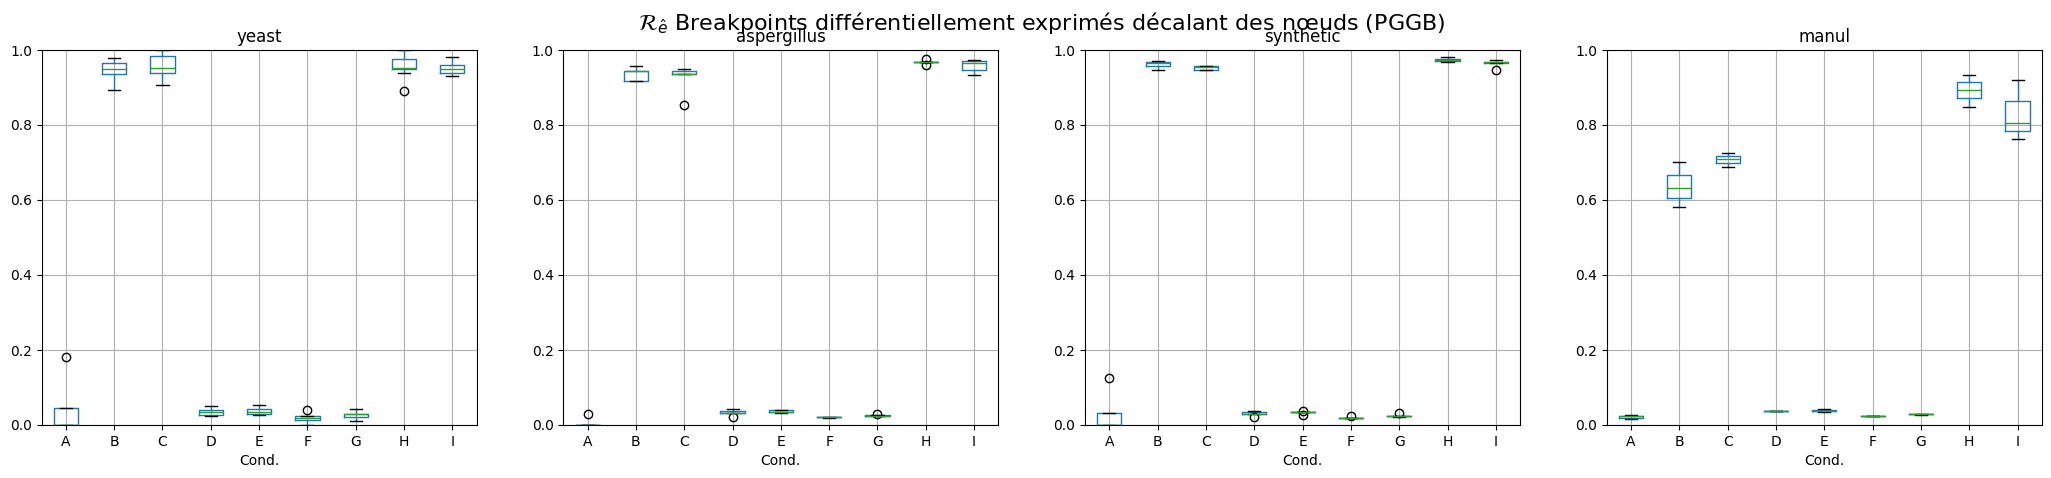

In [47]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df2.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Rm_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_\\hat{m}$ Breakpoints différentiellement exprimés découpant des nœuds (PGGB)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df2.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Rs_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_\\hat{s}$ Breakpoints différentiellement exprimés regroupant des nœuds (PGGB)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df2.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="Re_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('$\\mathcal{R}_\\hat{e}$ Breakpoints différentiellement exprimés décalant des nœuds (PGGB)', fontsize=16)

Text(0.5, 0.98, 'Chaînage des points de rupture différentiellement exprimés (scénario insertions/délétions)')

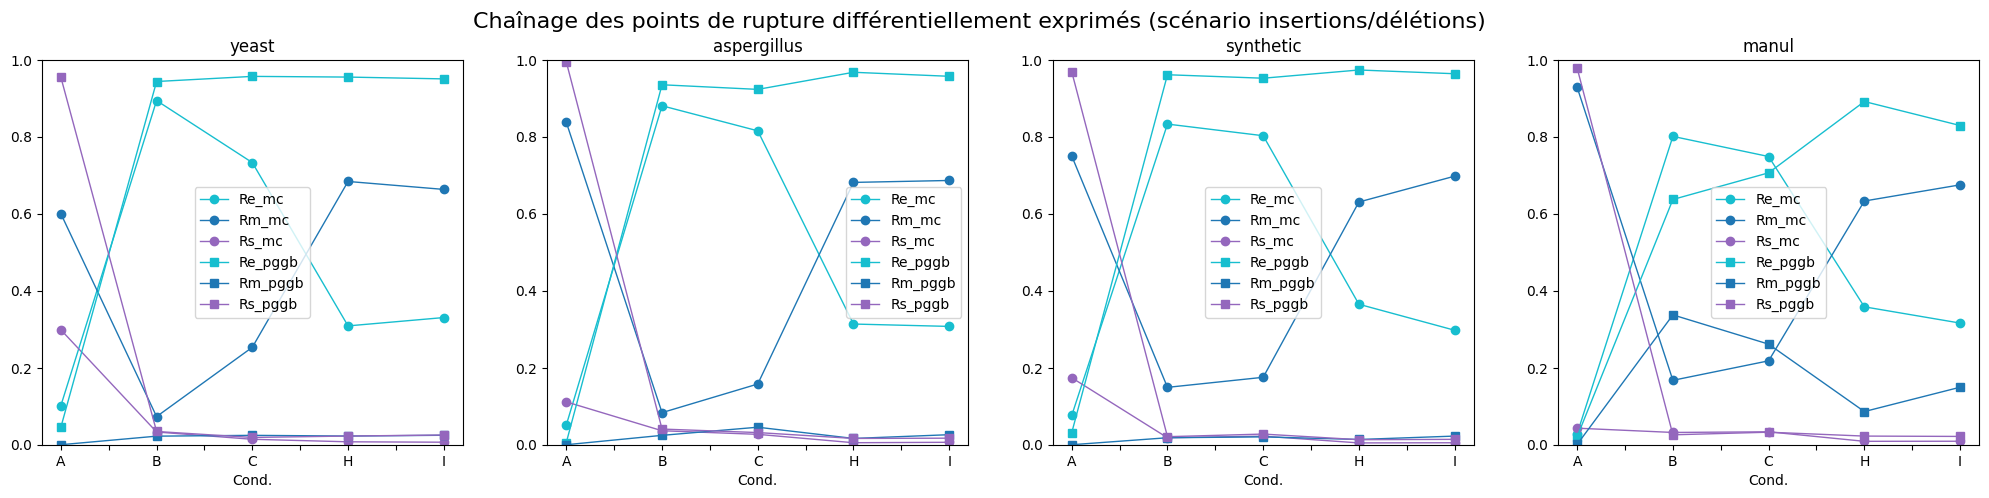

In [48]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df_indel_2.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").Re_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{e}$ (MC)",color='tab:cyan',linewidth=1,marker='o')
    cl.groupby("Cond.").Rm_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{m}$ (MC)",color='tab:blue',linewidth=1,marker='o')
    cl.groupby("Cond.").Rs_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{s}$ (MC)",color='tab:purple',linewidth=1,marker='o')
    cl.groupby("Cond.").Re_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{e}$ (PGGB)",color='tab:cyan',linewidth=1,marker='s')
    cl.groupby("Cond.").Rm_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{m}$ (PGGB)",color='tab:blue',linewidth=1,marker='s')
    cl.groupby("Cond.").Rs_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{s}$ (PGGB)",color='tab:purple',linewidth=1,marker='s')
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Chaînage des points de rupture différentiellement exprimés (scénario insertions/délétions)', fontsize=16)

Text(0.5, 0.98, 'Chaînage des points de rupture différentiellement exprimés (scénario inversions)')

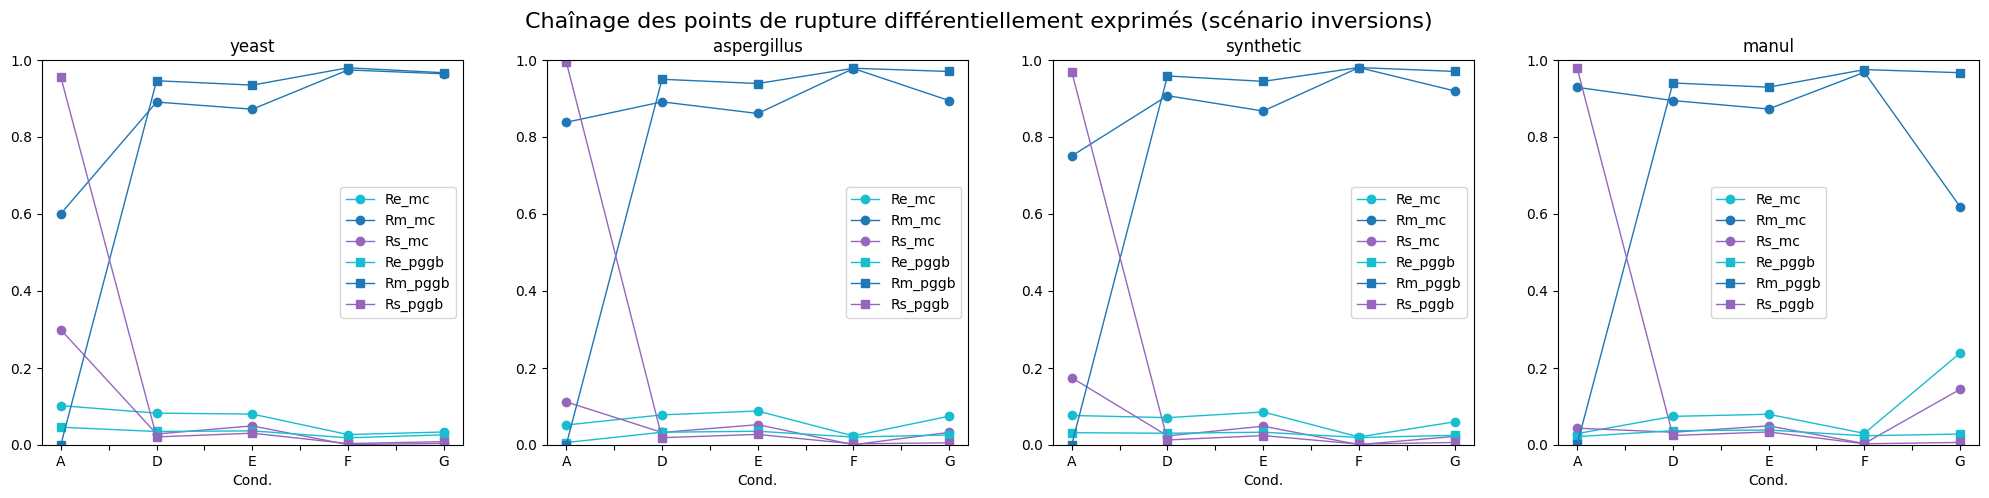

In [49]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df_inv_2.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").Re_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{e}$ (MC)",color='tab:cyan',linewidth=1,marker='o')
    cl.groupby("Cond.").Rm_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{m}$ (MC)",color='tab:blue',linewidth=1,marker='o')
    cl.groupby("Cond.").Rs_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{s}$ (MC)",color='tab:purple',linewidth=1,marker='o')
    cl.groupby("Cond.").Re_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{e}$ (PGGB)",color='tab:cyan',linewidth=1,marker='s')
    cl.groupby("Cond.").Rm_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{m}$ (PGGB)",color='tab:blue',linewidth=1,marker='s')
    cl.groupby("Cond.").Rs_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="$\\mathcal{R}_\\hat{s}$ (PGGB)",color='tab:purple',linewidth=1,marker='s')
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].set_ylim(0,1)
fig.suptitle('Chaînage des points de rupture différentiellement exprimés (scénario inversions)', fontsize=16)

In [50]:
df3:pandas.DataFrame = pandas.read_csv('variants.csv')

df3

,Sp.,Cond.,µ,Rep.,nb_variants_ms,nb_variants_mc,nb_variants_pggb
0,manul,C,10000000.0,rep2,260144,260211,260225
1,yeast,C,10000000.0,rep10,1418,1418,1418
2,yeast,A,10000000.0,rep8,3312,3312,3312
3,aspergillus,A,10000000.0,rep3,19424,19424,19424
4,aspergillus,C,10000000.0,rep5,22586,22581,22598
...,...,...,...,...,...,...,...
202,synthetic,A,10000000.0,rep5,24842,24842,24842
203,synthetic,G,10000000.0,rep4,1045,14786,27040
204,synthetic,C,10000000.0,rep3,13905,13906,13904
205,synthetic,F,10000000.0,rep5,169,3109,4781


Text(0.5, 0.98, 'Nombre de variants (PGGB)')

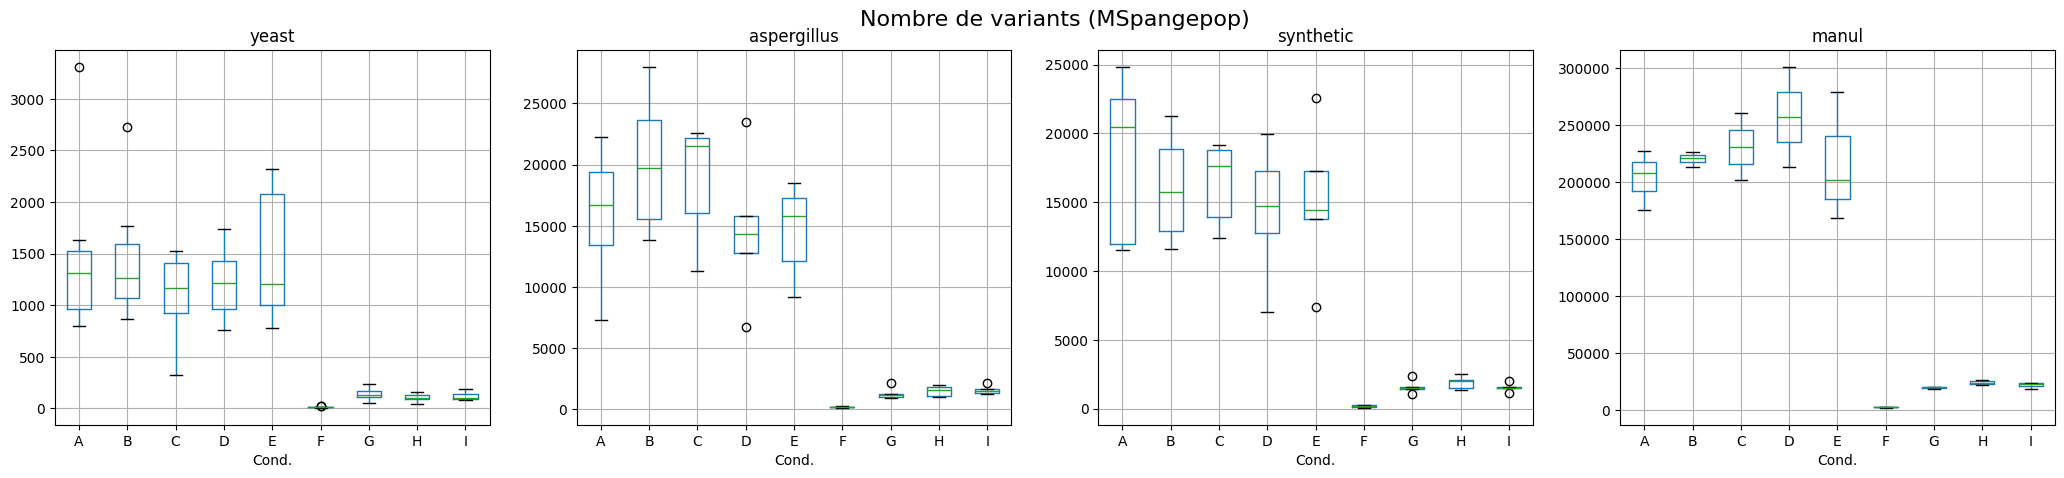

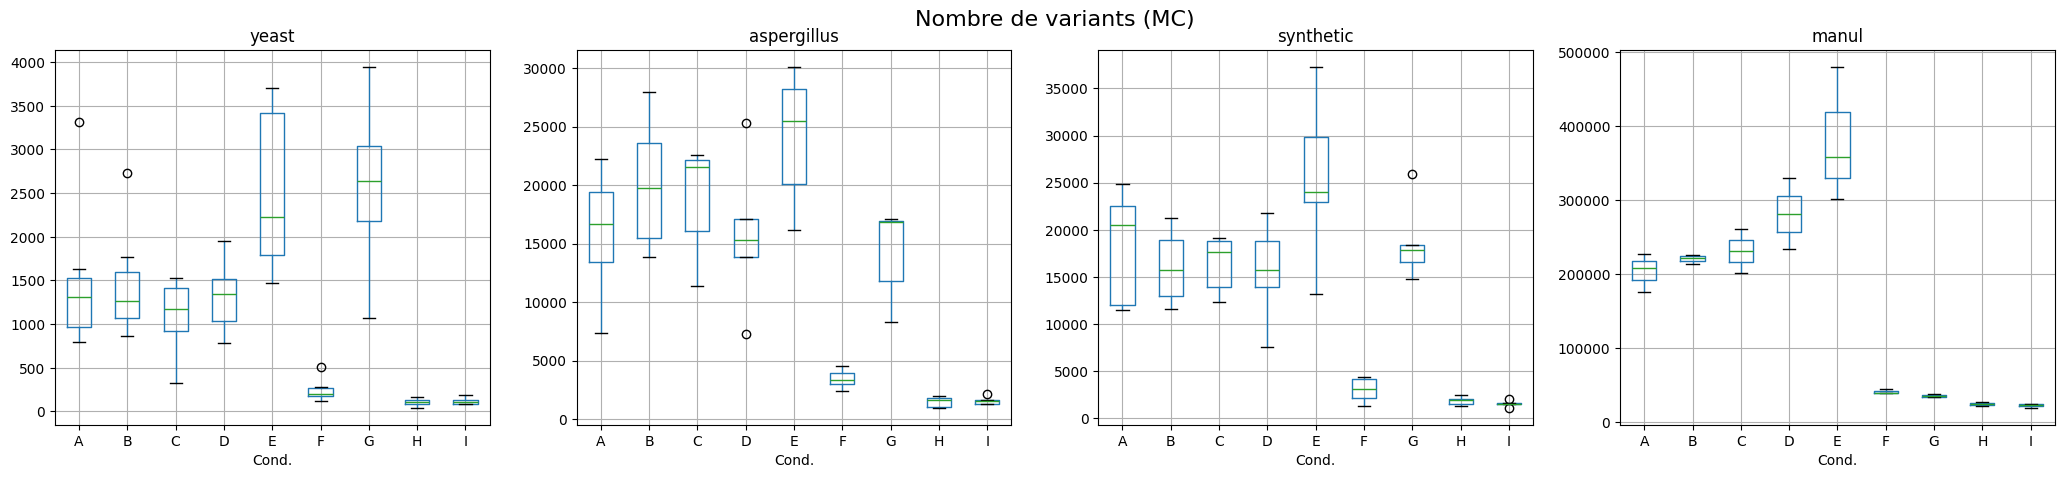

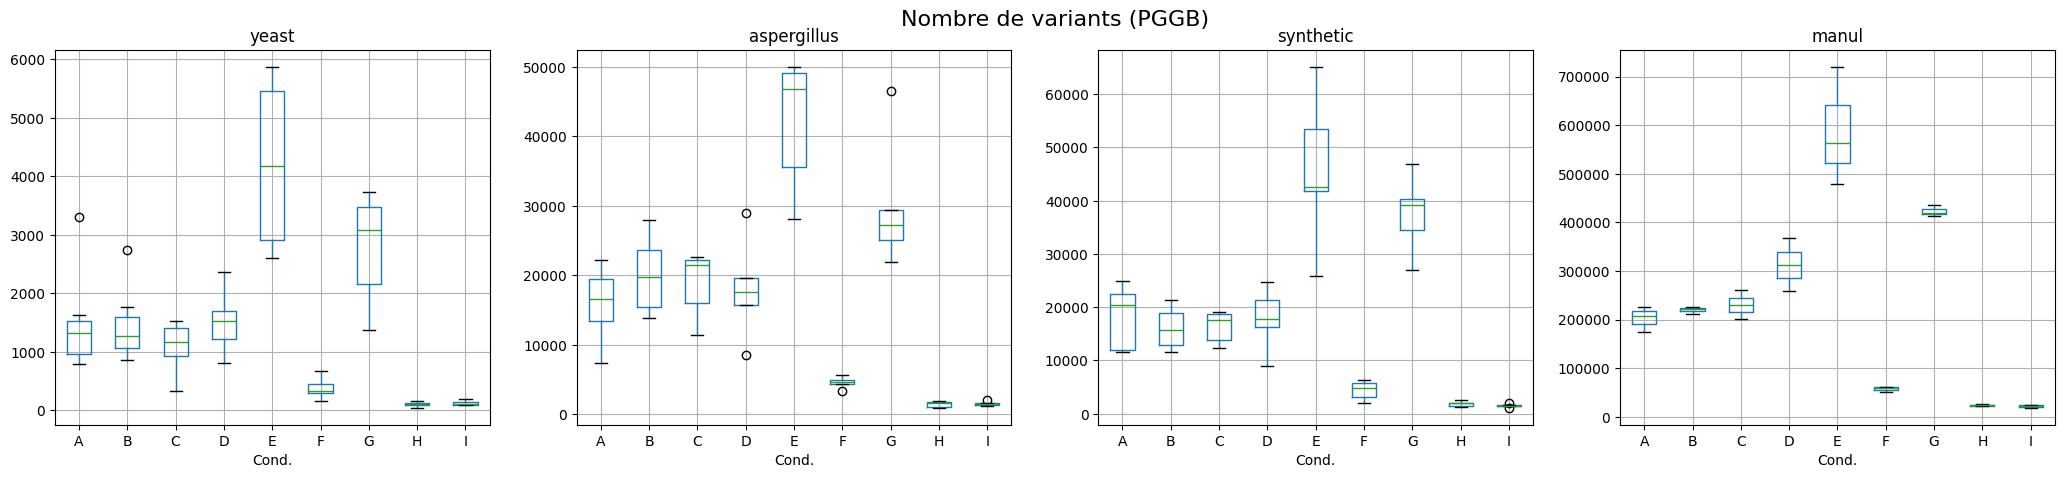

In [51]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df3.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="nb_variants_ms", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Nombre de variants (MSpangepop)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df3.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="nb_variants_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Nombre de variants (MC)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df3.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="nb_variants_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Nombre de variants (PGGB)', fontsize=16)

In [52]:
df4:pandas.DataFrame = pandas.read_csv('nodes.csv')

df4

,Sp.,Cond.,µ,Rep.,nb_nodes_ms,nb_nodes_mc,nb_nodes_pggb
0,manul,C,10000000.0,rep2,761004,763597,760987
1,yeast,C,10000000.0,rep10,4135,4142,4134
2,yeast,A,10000000.0,rep8,9987,9969,9969
3,aspergillus,A,10000000.0,rep3,58530,58589,58487
4,aspergillus,C,10000000.0,rep5,66247,66344,66250
...,...,...,...,...,...,...,...
141,synthetic,A,10000000.0,rep5,75048,75011,75005
142,synthetic,G,10000000.0,rep4,2233,49639,72055
143,synthetic,C,10000000.0,rep3,40586,40802,40558
144,synthetic,F,10000000.0,rep5,341,11573,12547


Text(0.5, 0.98, 'Nombre de nœuds (PGGB)')

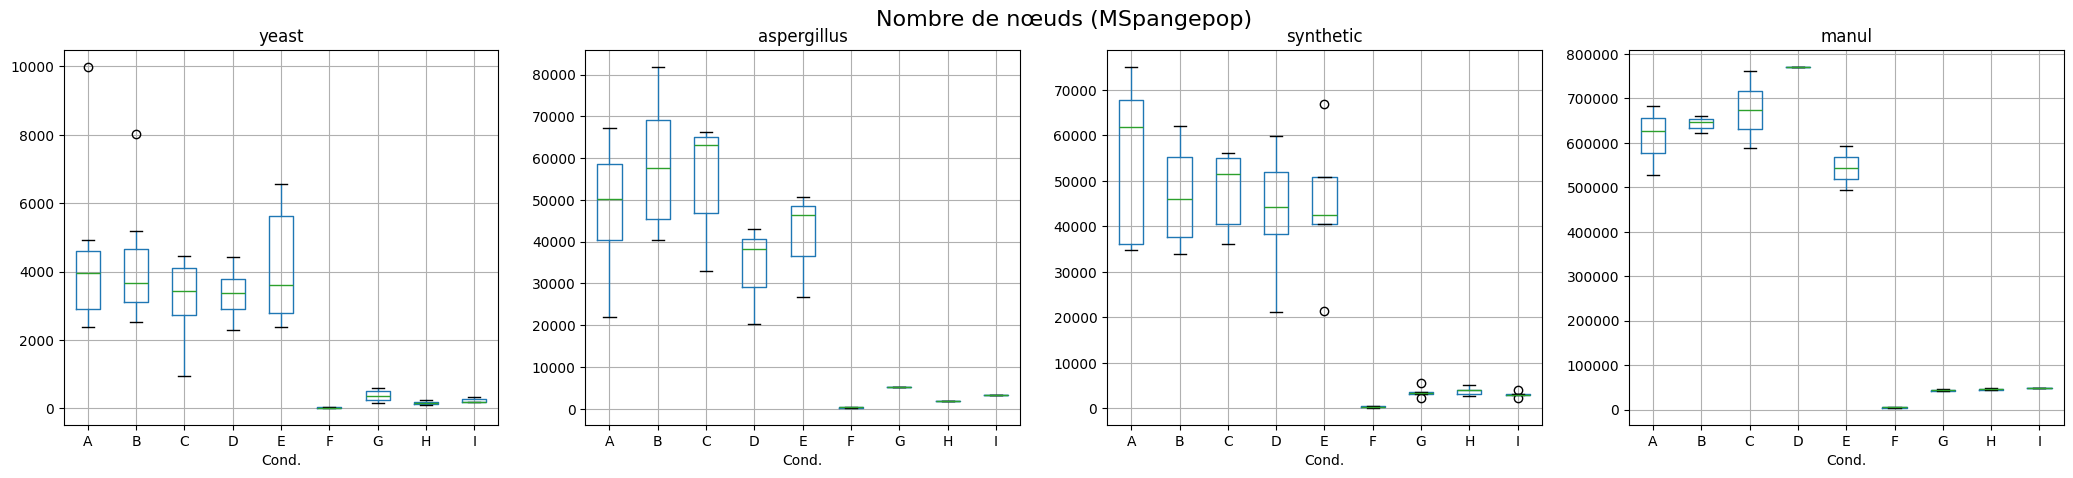

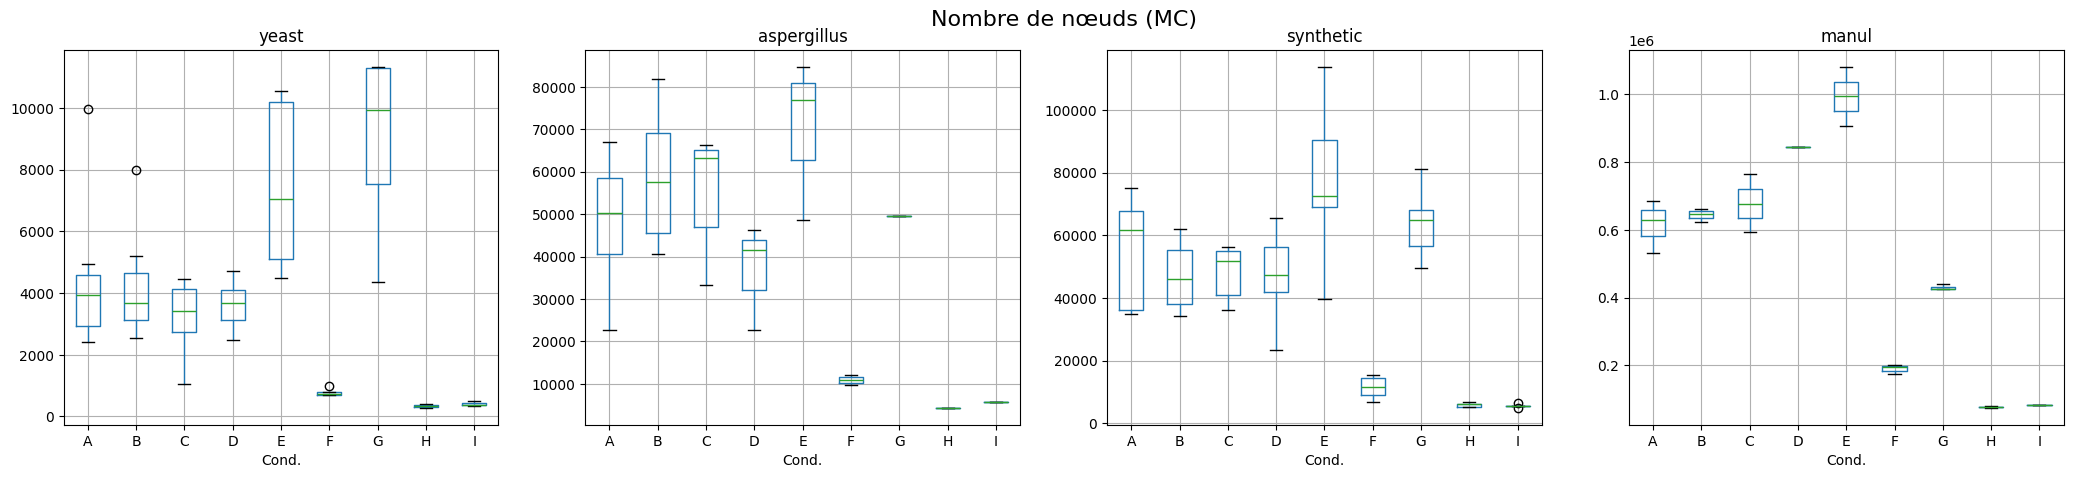

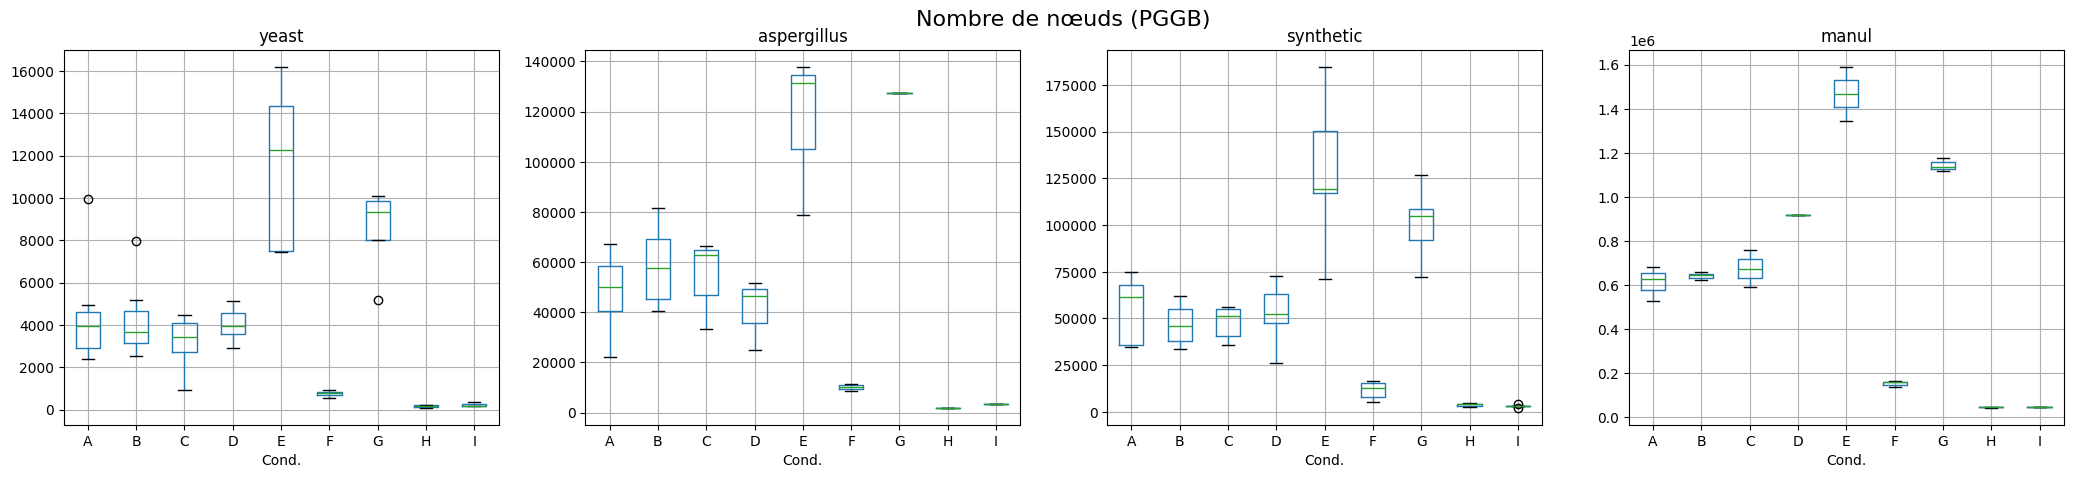

In [53]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df4.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="nb_nodes_ms", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Nombre de nœuds (MSpangepop)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df4.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="nb_nodes_mc", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Nombre de nœuds (MC)', fontsize=16)

fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df4.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="nb_nodes_pggb", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Nombre de nœuds (PGGB)', fontsize=16)

Comparaison tendance nombre de nœuds contre nombre de sites de variation

Text(0.5, 0.98, 'Comparaison du nombre de nœuds')

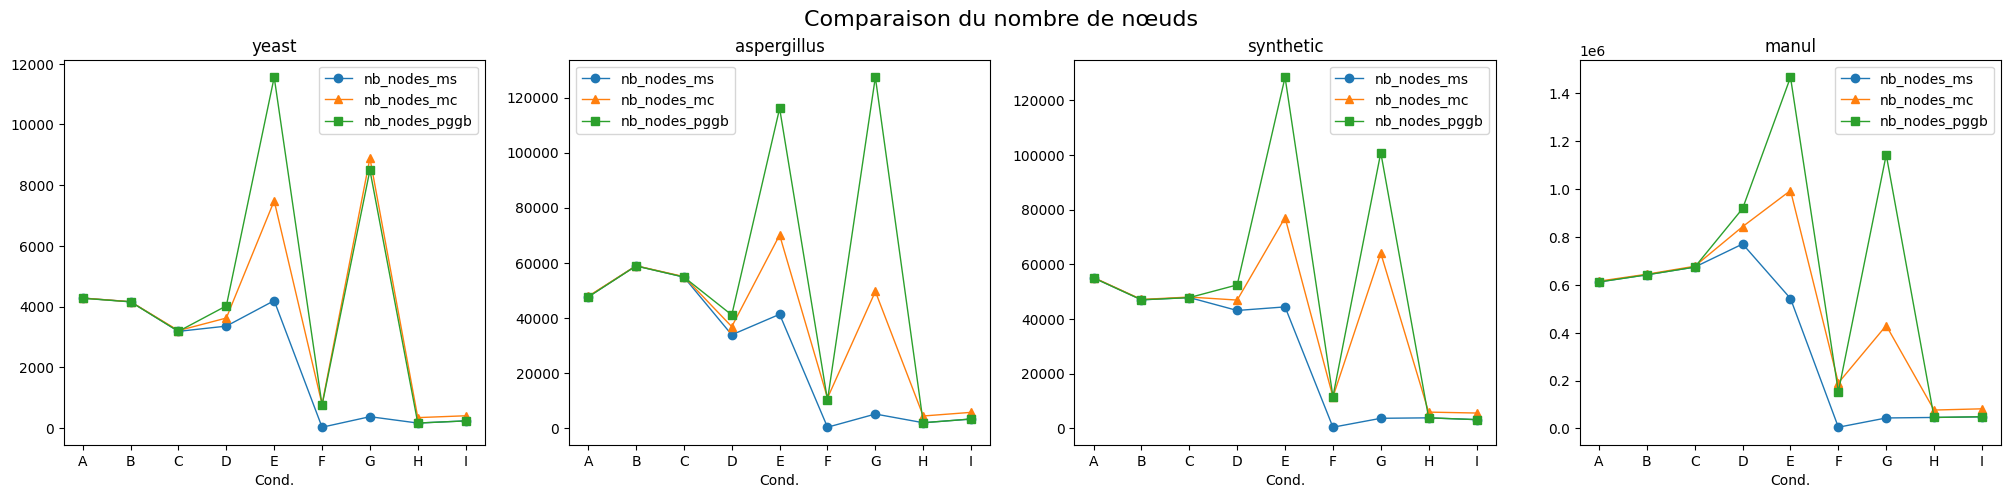

In [54]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df4.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").nb_nodes_ms.mean().plot(ax=axs[dict_assign[label_cond]],legend="MS",marker='o',linewidth=1)
    cl.groupby("Cond.").nb_nodes_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="MC",marker='^',linewidth=1)
    cl.groupby("Cond.").nb_nodes_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Comparaison du nombre de nœuds', fontsize=16)

Cond.
A     1.000655
B     1.000265
C     1.007856
D     1.079438
E     1.784093
F    33.127660
G    23.998650
H     2.111801
I     1.724534
dtype: float64
Cond.
A     0.999042
B     0.999110
C     1.000126
D     1.198818
E     2.755054
F    31.904255
G    22.925101
H     1.000000
I     0.998565
dtype: float64


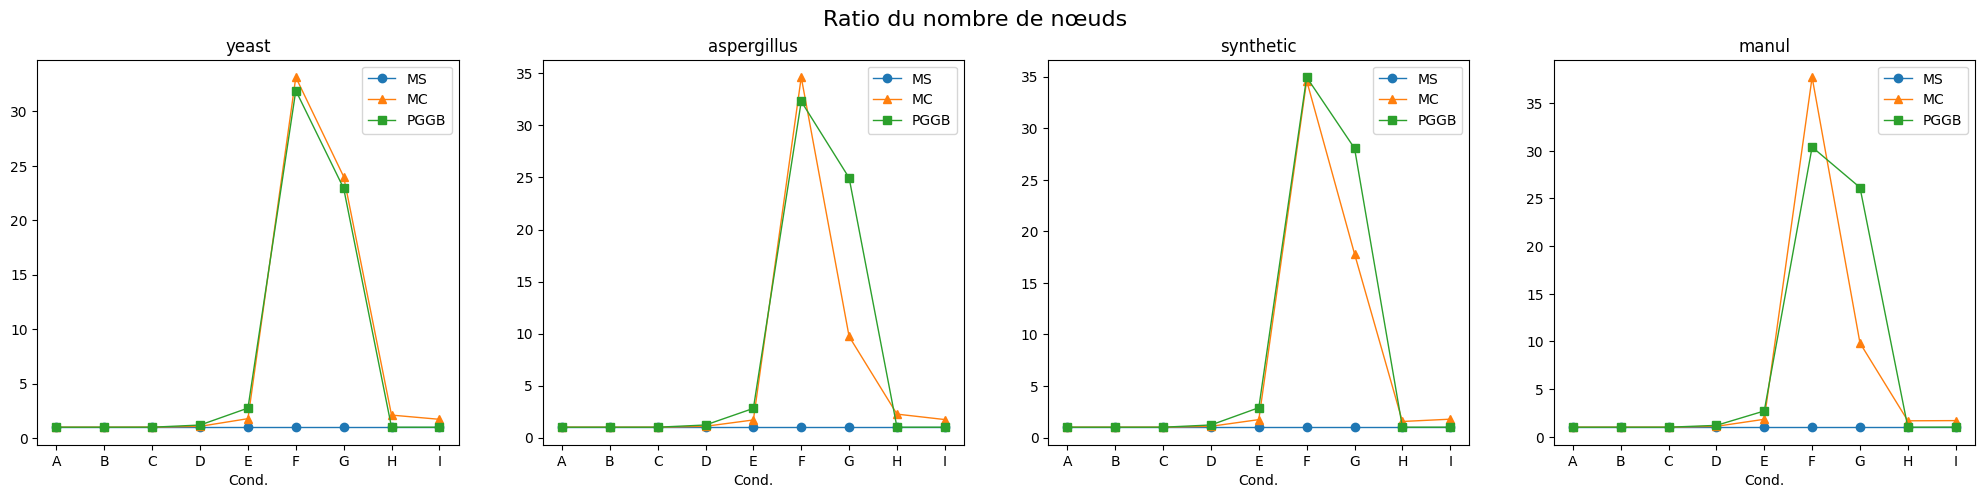

In [55]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df4.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    (cl.groupby("Cond.").nb_nodes_ms.mean()/cl.groupby("Cond.").nb_nodes_ms.mean()).plot(ax=axs[dict_assign[label_cond]],legend="MS",marker='o',linewidth=1)
    (cl.groupby("Cond.").nb_nodes_mc.mean()/cl.groupby("Cond.").nb_nodes_ms.mean()).plot(ax=axs[dict_assign[label_cond]],legend="MC",marker='^',linewidth=1)
    (cl.groupby("Cond.").nb_nodes_pggb.mean()/cl.groupby("Cond.").nb_nodes_ms.mean()).plot(ax=axs[dict_assign[label_cond]],legend="PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].legend(['MS', 'MC', 'PGGB'])
fig.suptitle('Ratio du nombre de nœuds', fontsize=16)

print(cl.groupby("Cond.").nb_nodes_mc.mean()/cl.groupby("Cond.").nb_nodes_ms.mean())
print(cl.groupby("Cond.").nb_nodes_pggb.mean()/cl.groupby("Cond.").nb_nodes_ms.mean())

Text(0.5, 0.98, 'Comparaison du nombre de sites de variation (vg deconstruct)')

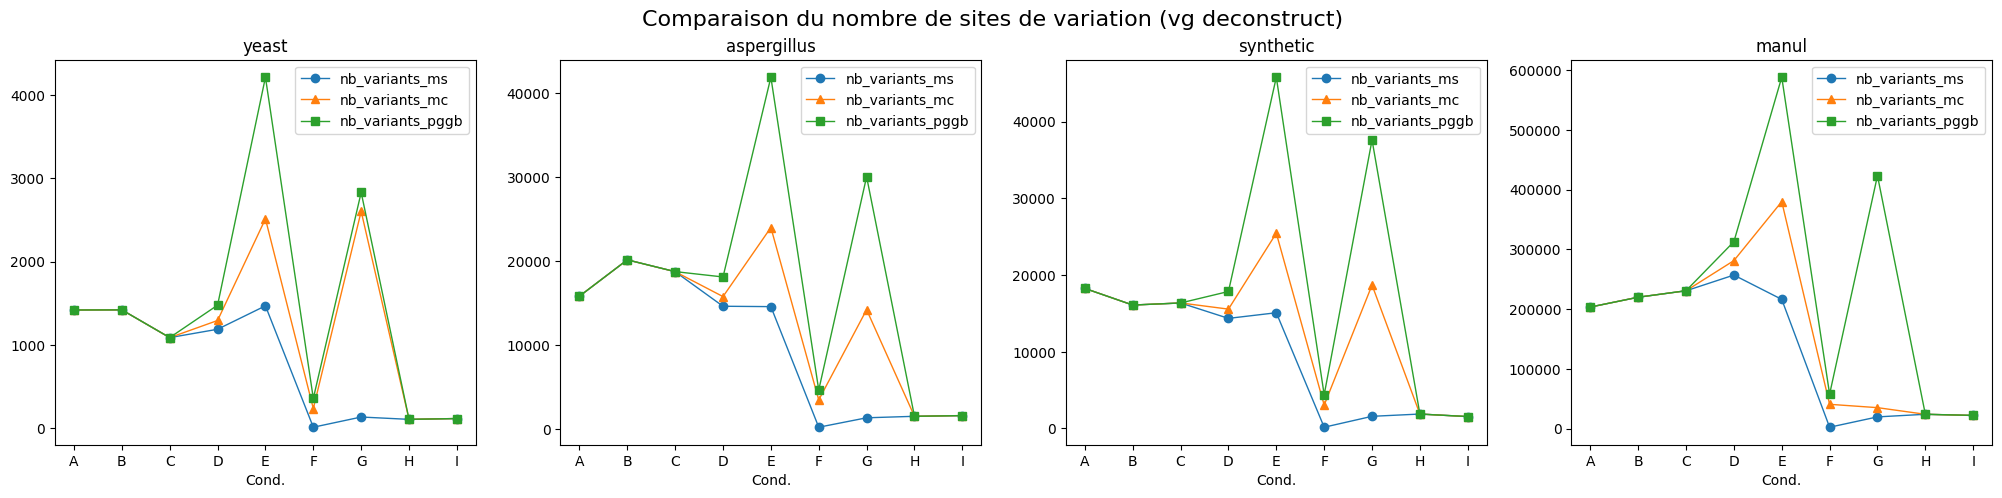

In [56]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df3.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.groupby("Cond.").nb_variants_ms.mean().plot(ax=axs[dict_assign[label_cond]],legend="MS",marker='o',linewidth=1)
    cl.groupby("Cond.").nb_variants_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="MC",marker='^',linewidth=1)
    cl.groupby("Cond.").nb_variants_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Comparaison du nombre de sites de variation (vg deconstruct)', fontsize=16)

Text(0.5, 0.98, 'Caractéristiques des graphes (Chat de Pallas)')

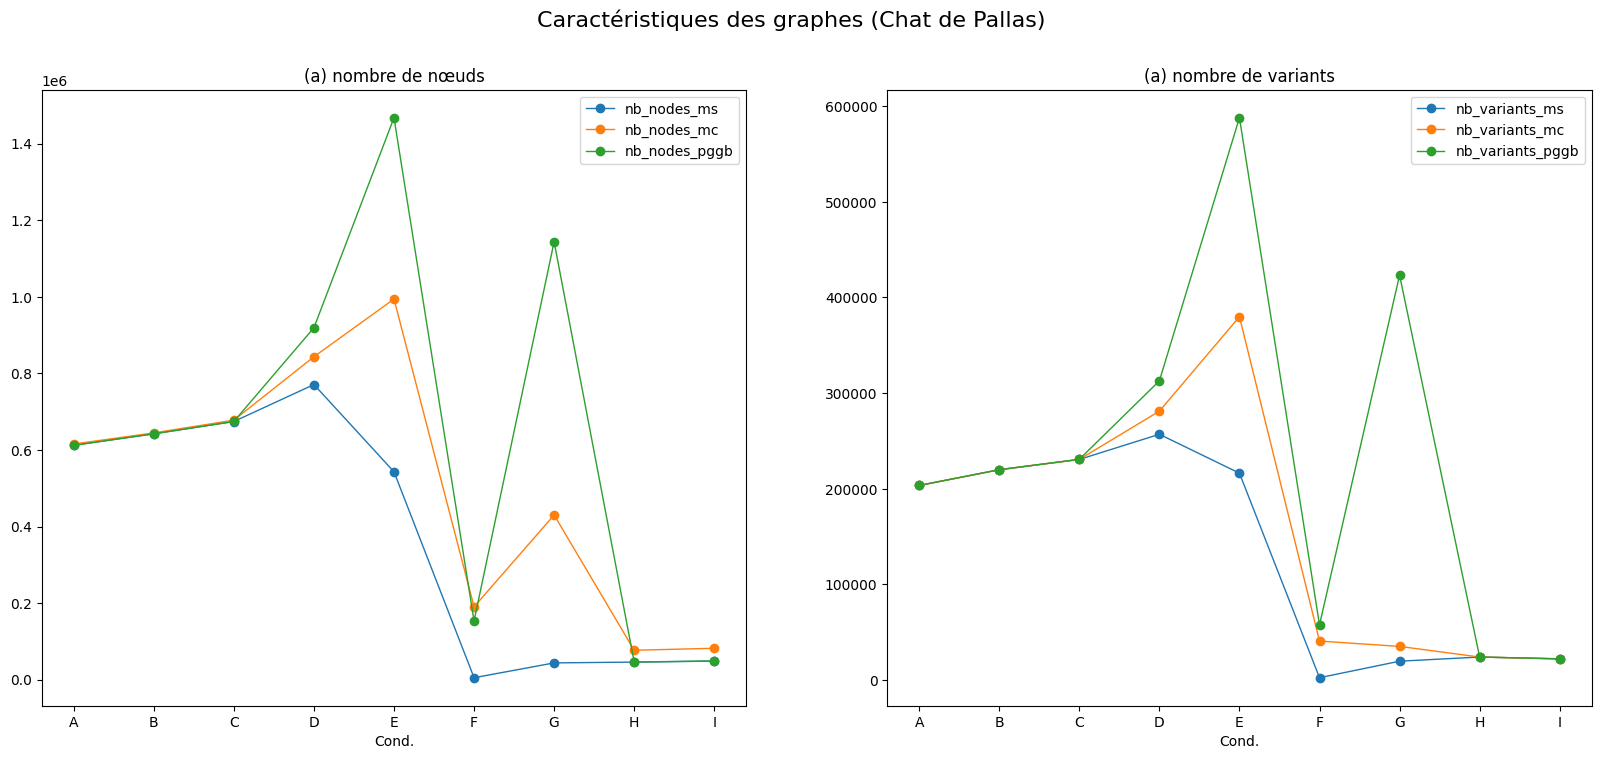

In [60]:
fig, (axs,axd) = plt.subplots(1,2,figsize=(20,8))
for label_cond,cl in df4.groupby('Sp.'):
    if label_cond == 'manul':
        cl.groupby("Cond.").nb_nodes_ms.mean().plot(ax=axs,legend="Précision MC",marker='o',linewidth=1)
        cl.groupby("Cond.").nb_nodes_mc.mean().plot(ax=axs,legend="Recall MC",marker='o',linewidth=1)
        cl.groupby("Cond.").nb_nodes_pggb.mean().plot(ax=axs,legend="Précision PGGB",marker='o',linewidth=1)
        axs.set_title("(a) nombre de nœuds")
for label_cond,cl in df3.groupby('Sp.'):
    if label_cond == 'manul':
        cl.groupby("Cond.").nb_variants_ms.mean().plot(ax=axd,legend="Précision MC",marker='o',linewidth=1)
        cl.groupby("Cond.").nb_variants_mc.mean().plot(ax=axd,legend="Recall MC",marker='o',linewidth=1)
        cl.groupby("Cond.").nb_variants_pggb.mean().plot(ax=axd,legend="Précision PGGB",marker='o',linewidth=1)
        axd.set_title("(a) nombre de variants")

fig.suptitle('Caractéristiques des graphes (Chat de Pallas)', fontsize=16)

Cond.
A     1.000000
B     0.999719
C     1.000092
D     1.088584
E     1.710408
F    18.523438
G    19.260355
H     1.000000
I     1.002562
dtype: float64
Cond.
A     1.000000
B     0.999789
C     1.000459
D     1.243291
E     2.866735
F    28.015625
G    20.943047
H     1.000000
I     0.999146
dtype: float64


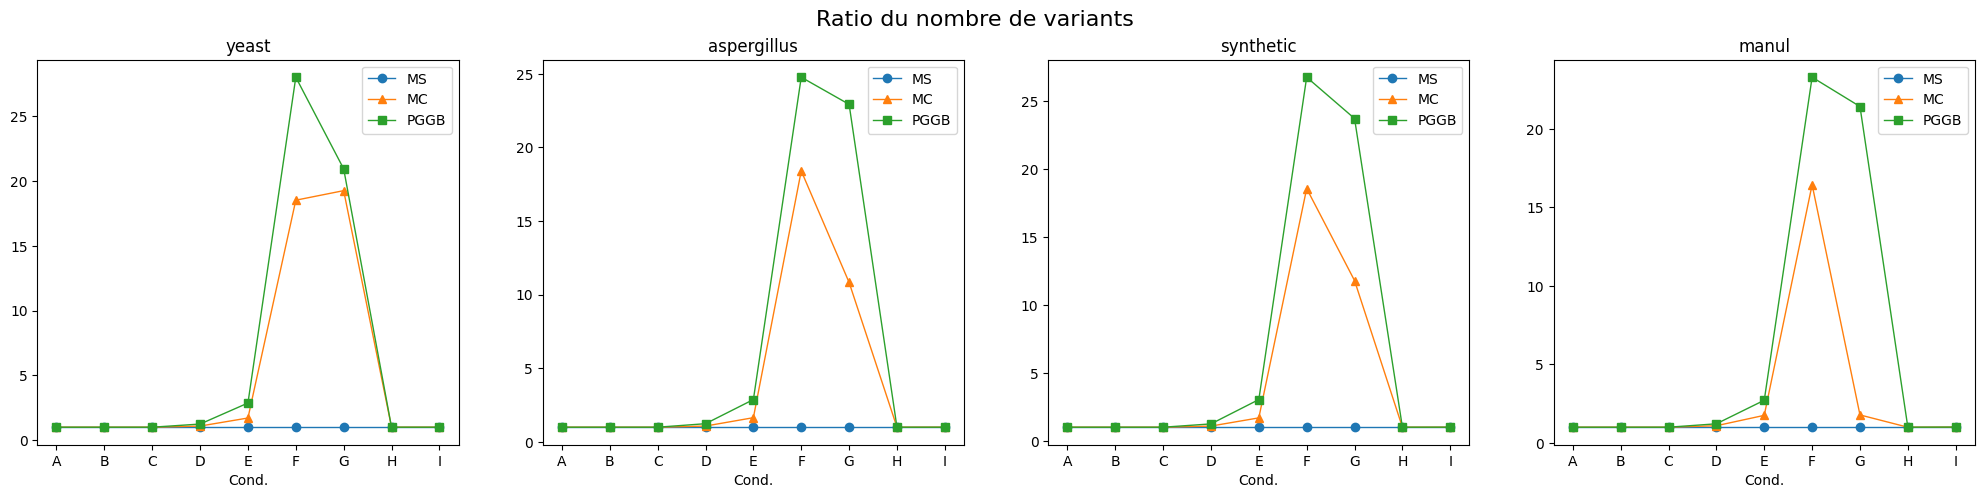

In [ ]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df3.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    (cl.groupby("Cond.").nb_variants_ms.mean()/cl.groupby("Cond.").nb_variants_ms.mean()).plot(ax=axs[dict_assign[label_cond]],legend="MS",marker='o',linewidth=1)
    (cl.groupby("Cond.").nb_variants_mc.mean()/cl.groupby("Cond.").nb_variants_ms.mean()).plot(ax=axs[dict_assign[label_cond]],legend="MC",marker='^',linewidth=1)
    (cl.groupby("Cond.").nb_variants_pggb.mean()/cl.groupby("Cond.").nb_variants_ms.mean()).plot(ax=axs[dict_assign[label_cond]],legend="PGGB",marker='s',linewidth=1)
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        axs[val].legend(['MS', 'MC', 'PGGB'])
fig.suptitle('Ratio du nombre de variants', fontsize=16)

print(cl.groupby("Cond.").nb_variants_mc.mean()/cl.groupby("Cond.").nb_variants_ms.mean())
print(cl.groupby("Cond.").nb_variants_pggb.mean()/cl.groupby("Cond.").nb_variants_ms.mean())

Comparaison nombre de sites de variation vg deconstruct et mspangepop sur graphes mspangepop

Distances entre séquences

In [ ]:
df5:pandas.DataFrame = pandas.read_csv('distance.csv')

df5

,Sp.,Cond.,µ,Rep.,mash
0,manul,C,10000000.0,rep2,0.002398
1,yeast,C,10000000.0,rep10,0.001902
2,yeast,A,10000000.0,rep8,0.003253
3,aspergillus,A,10000000.0,rep3,0.001974
4,aspergillus,C,10000000.0,rep5,0.003351
...,...,...,...,...,...
202,synthetic,A,10000000.0,rep5,0.003449
203,synthetic,G,10000000.0,rep4,0.000276
204,synthetic,C,10000000.0,rep3,0.002319
205,synthetic,F,10000000.0,rep5,0.000050


Text(0.5, 0.98, 'Distance mash moyenne entre séquences')

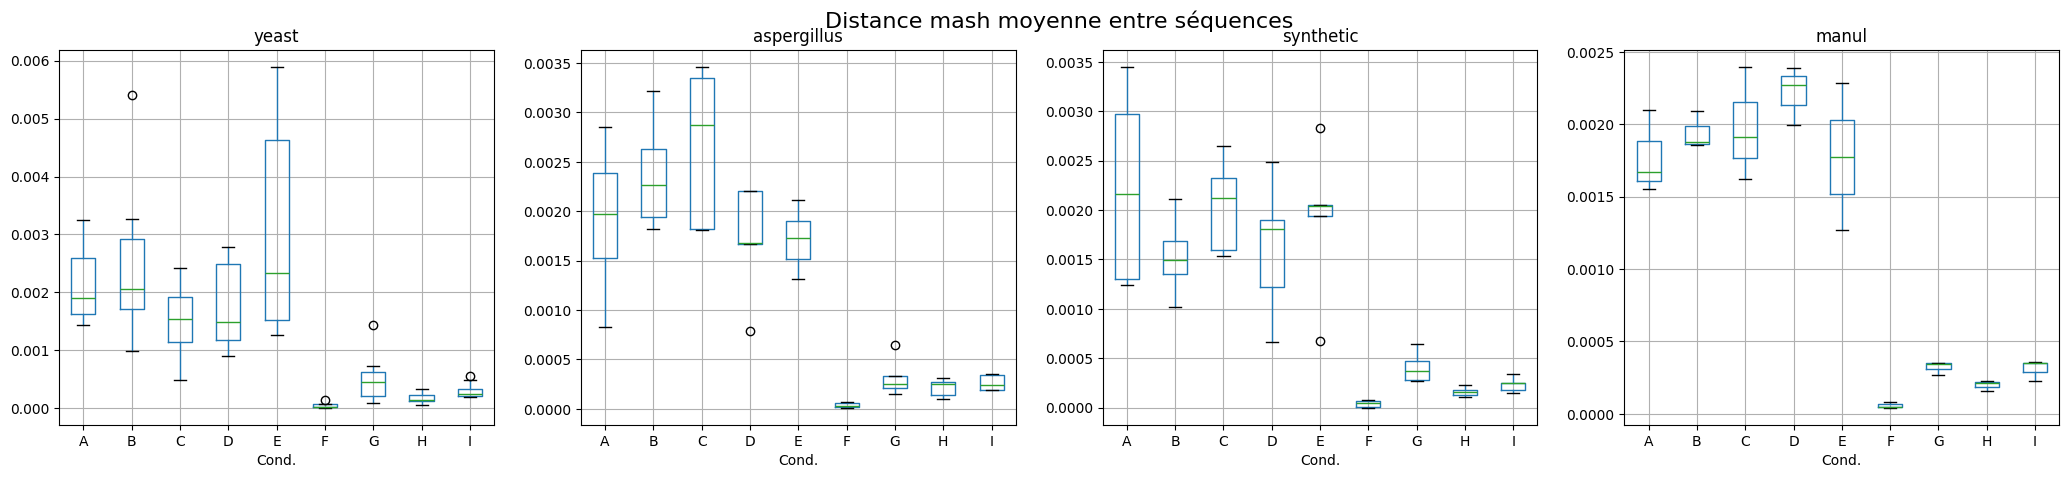

In [ ]:
fig, axs = plt.subplots(1,4,figsize=(25,5))
for label_cond,cl in df5.groupby('Sp.'):
    dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
    cl.boxplot(column="mash", by="Cond.", ax=axs[dict_assign[label_cond]])
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Distance mash moyenne entre séquences', fontsize=16)

Visualisation des localisations des breakpoints

1.320397495403275
dict_keys(['editions-mean', 'editions-stdev', 'lengths', 'ratios'])
dict_keys(['editions-mean', 'editions-stdev', 'lengths', 'ratios'])
2.617383516626599


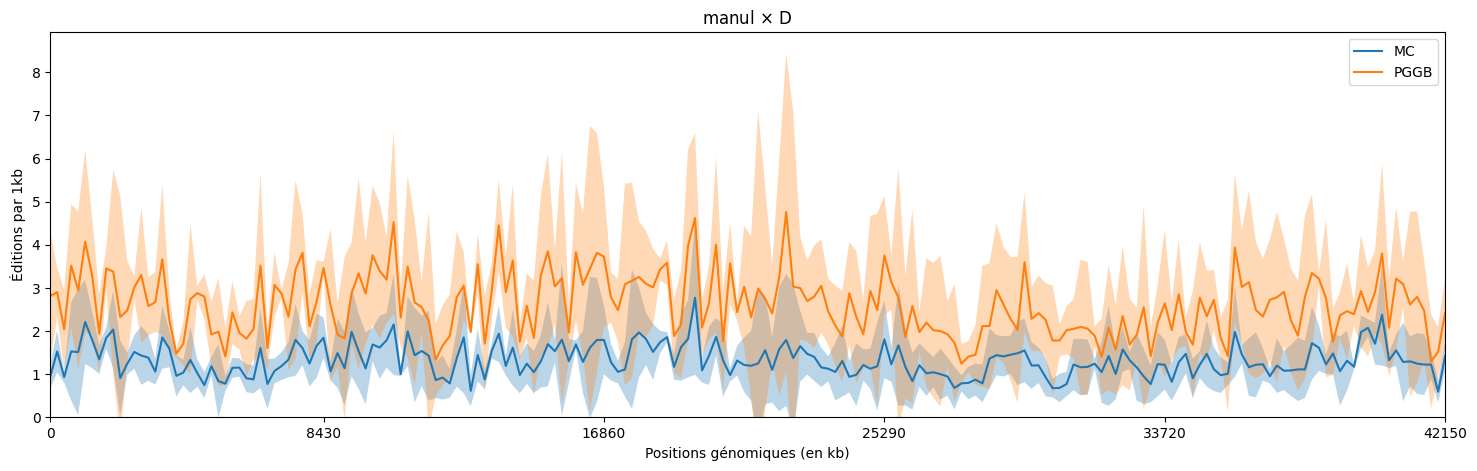

<Figure size 640x480 with 0 Axes>

In [ ]:
from json import load
from matplotlib import rc
from matplotlib import pyplot as plt
from random import choice
from statistics import mean,stdev

all_results:list = load(open('editions_120126.json', 'r'))

specie:str = 'manul'
condition:str = 'D'
software:str = 'mc'

sampling: int = 200
selected_results:list = [x for x in all_results if x['condition'] == condition and x['specie'] == specie and x['software'] == software]

edition_results:dict = {}
edition_results['editions-mean'] = [mean([selected_results[i]['editions-mean'][y] for i in range(len(selected_results))]) for y in range(sampling)]
edition_results['editions-stdev'] = [stdev([selected_results[i]['editions-mean'][y] for i in range(len(selected_results))]) for y in range(sampling)]
edition_results['lengths'] = mean([selected_results[i]['lengths'] for i in range(len(selected_results))])
edition_results['ratios'] = mean([selected_results[i]['ratios'] for i in range(len(selected_results))])
print(mean([ce/(reference_length/sampling)*kb for ce in edition_results['editions-mean']]))
reference_length: int = edition_results['lengths']
ratios:float = edition_results['ratios']

#font = {'size': 20}
#rc('font', **font)
kb:int = 1000

# Colorblind-friendly palette
colors:dict[str,str] = {
    'blue':    '#377eb8', 
    'orange':  '#ff7f00',
    'green':   '#4daf4a',
    'pink':    '#f781bf',
    'brown':   '#a65628',
    'purple':  '#984ea3',
    'gray':    '#999999',
    'red':     '#e41a1c',
    'yellow':  '#dede00'
}

print(edition_results.keys())

fig, ax = plt.subplots(figsize=(18,5))
ax.plot(list(range(sampling)),[ce/(reference_length/sampling)*kb for ce in edition_results['editions-mean']],label='MC')
ax.fill_between(list(range(sampling)),[(edition_results['editions-mean'][i]-edition_results['editions-stdev'][i])/(reference_length/sampling)*kb for i in range(sampling)],[(edition_results['editions-mean'][i]+edition_results['editions-stdev'][i])/(reference_length/sampling)*kb for i in range(sampling)], alpha=.3)

specie:str = 'manul'
software:str = 'pggb'

sampling: int = 200
selected_results:list = [x for x in all_results if x['condition'] == condition and x['specie'] == specie and x['software'] == software]

edition_results:dict = {}
edition_results['editions-mean'] = [mean([selected_results[i]['editions-mean'][y] for i in range(len(selected_results))]) for y in range(sampling)]
edition_results['editions-stdev'] = [stdev([selected_results[i]['editions-mean'][y] for i in range(len(selected_results))]) for y in range(sampling)]
edition_results['lengths'] = mean([selected_results[i]['lengths'] for i in range(len(selected_results))])
edition_results['ratios'] = mean([selected_results[i]['ratios'] for i in range(len(selected_results))])

reference_length: int = edition_results['lengths']
ratios:float = edition_results['ratios']

#font = {'size': 20}
#rc('font', **font)
kb:int = 1000

# Colorblind-friendly palette
colors:dict[str,str] = {
    'blue':    '#377eb8', 
    'orange':  '#ff7f00',
    'green':   '#4daf4a',
    'pink':    '#f781bf',
    'brown':   '#a65628',
    'purple':  '#984ea3',
    'gray':    '#999999',
    'red':     '#e41a1c',
    'yellow':  '#dede00'
}

print(edition_results.keys())

ax.plot(list(range(sampling)),[ce/(reference_length/sampling)*kb for ce in edition_results['editions-mean']],label='PGGB')
ax.fill_between(list(range(sampling)),[(edition_results['editions-mean'][i]-edition_results['editions-stdev'][i])/(reference_length/sampling)*kb for i in range(sampling)],[(edition_results['editions-mean'][i]+edition_results['editions-stdev'][i])/(reference_length/sampling)*kb for i in range(sampling)], alpha=.3)

ax.set_ylabel(f'Éditions par 1kb')
ax.set_xlabel(f'Positions génomiques (en kb)')
ax.legend(loc=(.13,.73),frameon=False)
ax.set_xlim(left=0,right=sampling-1)
ax.set_xticks([0]+[__-1 for __ in range(1,sampling+2) if not __%40])
ax.set_xticklabels(['0']+[int(round(__/ratios,-4)/1000) for __ in range(1,sampling+2) if not __%40])
ax.set_ylim(bottom=0)
print(mean([ce/(reference_length/sampling)*kb for ce in edition_results['editions-mean']]))
ax.set_title(f"{specie} $\\times$ {condition}")
ax.legend()

plt.show()
plt.clf()

dict_keys(['editions-mean', 'editions-stdev', 'lengths', 'ratios'])


/tmp/ipykernel_26234/2425137279.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=(.13,.73),frameon=False)


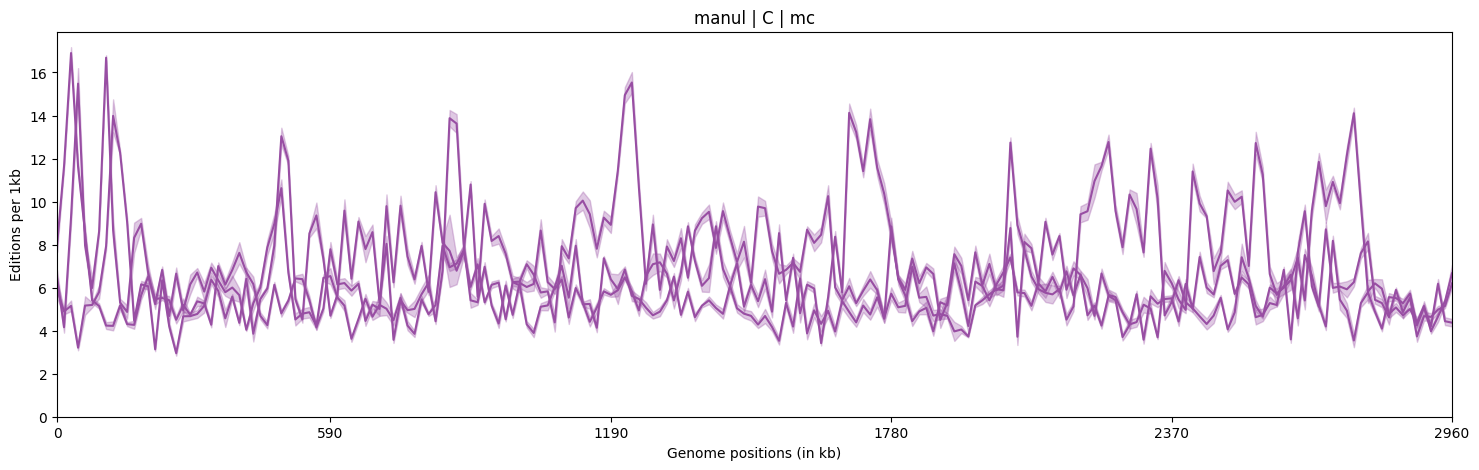

<Figure size 640x480 with 0 Axes>

In [ ]:
from json import load
from matplotlib import rc
from matplotlib import pyplot as plt
from random import choice
from statistics import mean,stdev

all_results:list = load(open('editions_080126.json', 'r'))

specie:str = 'manul'
condition:str = 'C'
software:str = 'mc'

sampling: int = 200
selected_results:list = [x for x in all_results if x['condition'] == condition and x['specie'] == specie and x['software'] == software]

#edition_results:dict = {}
#edition_results['editions-mean'] = [mean([selected_results[i]['editions-mean'][y] for i in range(len(selected_results))]) for y in range(sampling)]
#edition_results['editions-stdev'] = [stdev([selected_results[i]['editions-mean'][y] for i in range(len(selected_results))]) for y in range(sampling)]
#edition_results['lengths'] = mean([selected_results[i]['lengths'] for i in range(len(selected_results))])
#edition_results['ratios'] = mean([selected_results[i]['ratios'] for i in range(len(selected_results))])

reference_length: int = edition_results['lengths']
ratios:float = edition_results['ratios']

#font = {'size': 20}
#rc('font', **font)
kb:int = 1000

# Colorblind-friendly palette
colors:dict[str,str] = {
    'blue':    '#377eb8', 
    'orange':  '#ff7f00',
    'green':   '#4daf4a',
    'pink':    '#f781bf',
    'brown':   '#a65628',
    'purple':  '#984ea3',
    'gray':    '#999999',
    'red':     '#e41a1c',
    'yellow':  '#dede00'
}

print(edition_results.keys())

fig, ax = plt.subplots(figsize=(18,5))
for edition_results in selected_results:
    ax.plot(list(range(sampling)),[ce/(reference_length/sampling)*kb for ce in edition_results['editions-mean']], color=colors['purple'])
    ax.fill_between(list(range(sampling)),[(edition_results['editions-mean'][i]-edition_results['editions-stdev'][i])/(reference_length/sampling)*kb for i in range(sampling)],[(edition_results['editions-mean'][i]+edition_results['editions-stdev'][i])/(reference_length/sampling)*kb for i in range(sampling)], alpha=.3, color=colors['purple'])
ax.set_ylabel(f'Editions per 1kb')
ax.set_xlabel(f'Genome positions (in kb)')
ax.legend(loc=(.13,.73),frameon=False)
ax.set_xlim(left=0,right=sampling-1)
ax.set_xticks([0]+[__-1 for __ in range(1,sampling+2) if not __%40])
ax.set_xticklabels(['0']+[int(round(__/ratios,-4)/1000) for __ in range(1,sampling+2) if not __%40])
ax.set_ylim(bottom=0)
ax.set_title(f"{specie} | {condition} | {software}")
plt.show()
plt.clf()

In [ ]:
print(
    'specie',
    'condition',
    'software',
    'ed_mean',
    'ed_stdev',
    sep=',',
    file=open('edits.csv','w')
)
sampling: int = 200
for filename in ['editions_080126.json','editions_120126.json','editions_290126.json']:
    all_results:list = load(open(filename, 'r'))
    for specie in ['yeast','aspergillus','synthetic','manul']:
        for condition in ['A','B','C','D','E','F','G','H','I']:
            for software in ['mc','pggb']:
                selected_results:list = [x for x in all_results if x['condition'] == condition and x['specie'] == specie and x['software'] == software]
                if len(selected_results):
                    reference_length: int = mean([selected_results[y]['lengths'] for y in range(len(selected_results))])
                    ed_mean = mean([mean([selected_results[i]['editions-mean'][y]/(reference_length/sampling)*kb for i in range(len(selected_results))]) for y in range(sampling)])
                    ed_stdev = mean([stdev([selected_results[i]['editions-mean'][y]/(reference_length/sampling)*kb for i in range(len(selected_results))]) for y in range(sampling)])
                    print(
                        specie,
                        condition,
                        software,
                        ed_mean,
                        ed_stdev,
                        sep=',',
                        file=open('edits.csv','a')
                    )



In [ ]:
df5:pandas.DataFrame = pandas.read_csv('edits.csv')

df5

,specie,condition,software,ed_mean,ed_stdev
0,yeast,A,mc,0.040463,0.111244
1,yeast,A,pggb,0.009711,0.030709
2,yeast,B,mc,0.497692,1.018768
3,yeast,B,pggb,0.477238,1.008598
4,yeast,C,mc,0.476187,0.853623
...,...,...,...,...,...
67,synthetic,G,pggb,22.213753,11.437780
68,synthetic,H,mc,1.120008,0.256866
69,synthetic,H,pggb,0.420972,0.301557
70,synthetic,I,mc,1.117622,0.242541


Text(0.5, 0.98, "Comparaison du nombre moyen d'éditions ($op. \\times kb^{-1}$)")

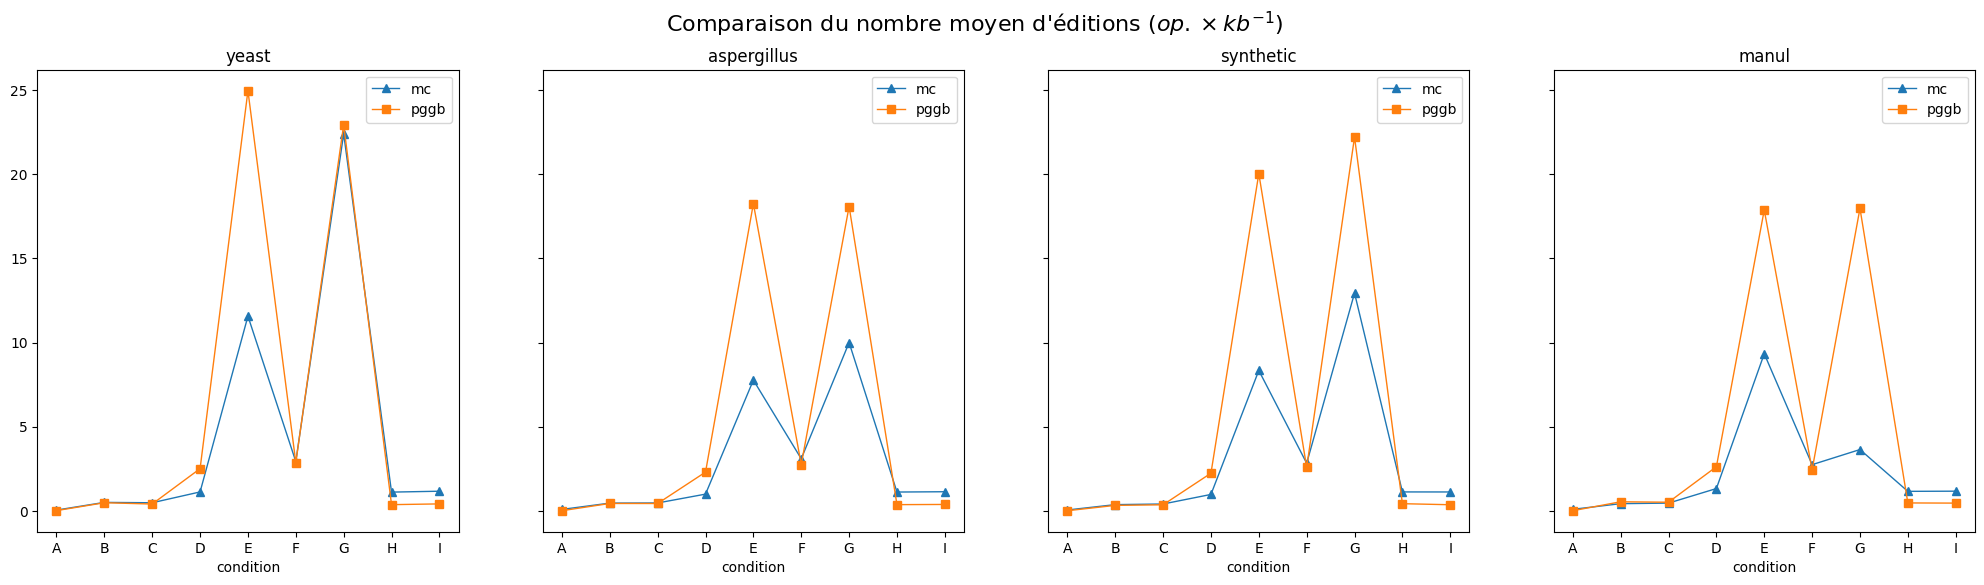

In [ ]:
fig, axs = plt.subplots(1,4,figsize=(25,6),sharey=True)
dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
for label_cond,cl in df5[df5['software'] == 'mc'].groupby('specie'):
    cl.groupby("condition").ed_mean.mean().plot(ax=axs[dict_assign[label_cond]],legend="MC",marker='^',linewidth=1,label='mc')
for label_cond,cl in df5[df5['software'] == 'pggb'].groupby('specie'):
    cl.groupby("condition").ed_mean.mean().plot(ax=axs[dict_assign[label_cond]],legend="PGGB",marker='s',linewidth=1,label='pggb')
    for key,val in dict_assign.items():
        axs[val].set_title(key)
fig.suptitle("Comparaison du nombre moyen d'éditions ($op. \\times kb^{-1}$)", fontsize=16)

In [ ]:
fig, axs = plt.subplots(1,4,figsize=(25,6),sharey=True)
dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}
for label_cond,cl in df5[df5['software'] == 'mc'].groupby('specie'):
    cl.groupby("condition").ed_mean.mean().plot(ax=axs[dict_assign[label_cond]],legend="MC",marker='^',linewidth=1,label='mc')
for label_cond,cl in df5[df5['software'] == 'pggb'].groupby('specie'):
    cl.groupby("condition").ed_mean.mean().plot(ax=axs[dict_assign[label_cond]],legend="PGGB",marker='s',linewidth=1,label='pggb')
    for key,val in dict_assign.items():
        axs[val].set_title(key)
fig.suptitle("Ratio du nombre moyen d'éditions ($op. \\times kb^{-1}$)", fontsize=16)

In [ ]:
df6:pandas.DataFrame = pandas.read_csv('kmers.csv')

df6

,Sp.,Cond.,Rep.,id,n
0,manul,C,rep2,manul_C_rep2#9#chr_1,1.015992e-01
1,manul,C,rep2,manul_C_rep2#6#chr_1,1.015272e-01
2,manul,C,rep2,manul_C_rep2#4#chr_1,1.015272e-01
3,manul,C,rep2,manul_C_rep2#8#chr_1,1.014923e-01
4,manul,C,rep2,manul_C_rep2#1#chr_1,1.015026e-01
...,...,...,...,...,...
2065,synthetic,E,rep5,synthetic_E_rep5#7#chr_1,6.666713e-07
2066,synthetic,E,rep5,synthetic_E_rep5#2#chr_1,6.666713e-07
2067,synthetic,E,rep5,synthetic_E_rep5#4#chr_1,6.666713e-07
2068,synthetic,E,rep5,synthetic_E_rep5#3#chr_1,6.666713e-07


In [ ]:
base_cov:dict = {
    'yeast':0.008552042913090202,
    'aspergillus':0.04067326144952563,
    'manul':0.1046375027233854,
    'synthetic':6.666713333660003e-07,
}

aspergillus,0.03914505745454076,0.0005168196573367416,False
manul,0.10315506317969478,0.00025986826878134393,False
synthetic,2.1353714898878457e-06,1.279523576059567e-06,False
yeast,0.009027364928583193,0.000781465880480735,True


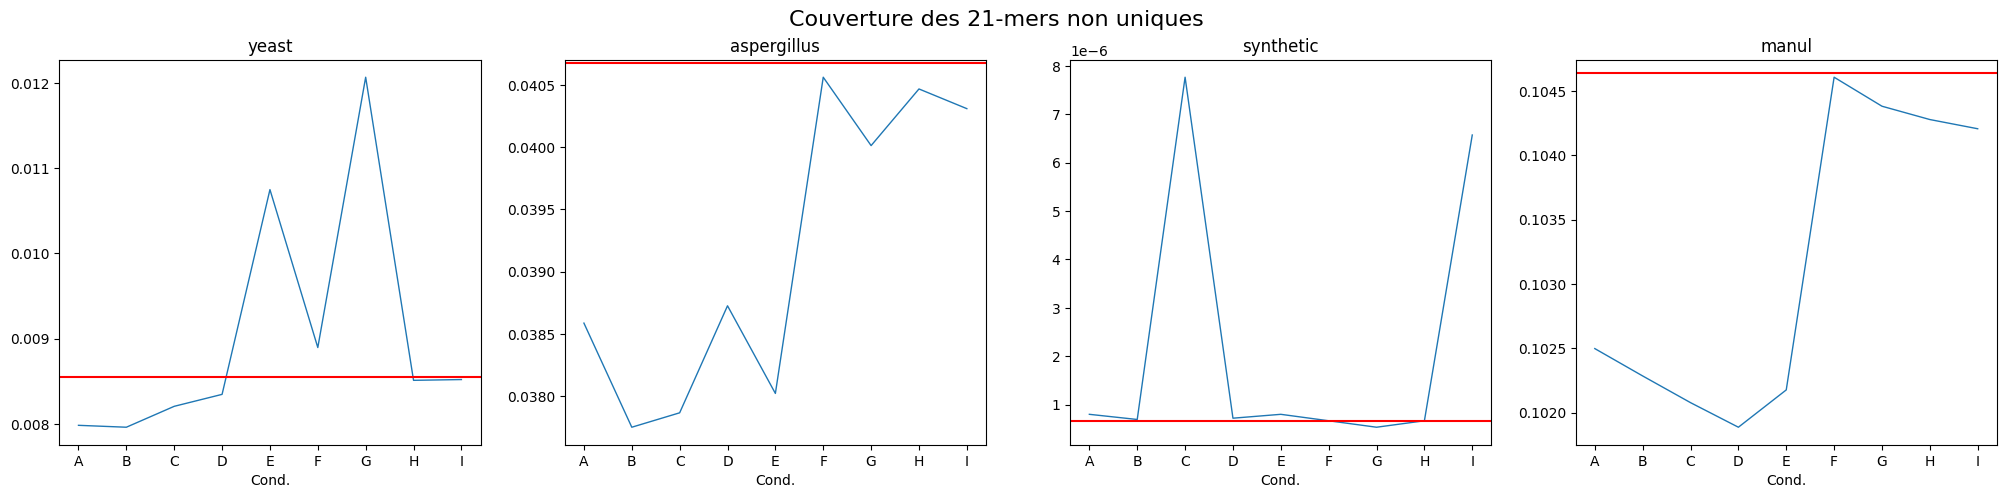

In [ ]:
import numpy as np

fig, axs = plt.subplots(1,4,figsize=(25,5))
dict_assign = {'yeast':0,'aspergillus':1,'synthetic':2,'manul':3}

#dfm = df.groupby(["Sp.","Cond."]).agg([np.mean, np.std])
#dfm["n"].unstack(level=0).plot(y = "mean", yerr = "std")
for label_cond,cl in df6.groupby('Sp.'):
    cl.groupby("Cond.").n.mean().plot(ax=axs[dict_assign[label_cond]],linewidth=1)
    #ax.plot(range(9),cl.groupby("Cond.").n.mean())
    #ax.fill_between(range(9),cl.groupby("Cond.").n.mean() - cl.groupby("Cond.").n.std(), cl.groupby("Cond.").n.mean() + cl.groupby("Cond.").n.std(), alpha=0.35)
for key,val in dict_assign.items():
    axs[val].axhline(y=base_cov[key], color='r')
    axs[val].set_title(key)
fig.suptitle("Couverture des 21-mers non uniques", fontsize=16)

for label_cond,cl in df6.groupby('Sp.'):
    tst = base_cov[label_cond] > mean(cl.groupby("Cond.").n.mean())-mean(cl.groupby("Cond.").n.std()) and base_cov[label_cond] < mean(cl.groupby("Cond.").n.mean())+mean(cl.groupby("Cond.").n.std())
    print(f"{label_cond},{mean(cl.groupby("Cond.").n.mean())},{mean(cl.groupby("Cond.").n.std())},{tst}")
